In [1]:
fn = '14repr'

In [2]:
import os
import time
import math
import joblib 

import tqdm
# def silent_tqdm(iterable=None, *args, **kwargs):
#     return iterable if iterable is not None else []

# # Patch all known entry points
# tqdm.tqdm = silent_tqdm
# try:
#     import tqdm.auto
#     tqdm.auto.tqdm = silent_tqdm
# except ImportError:
#     pass
# try:
#     import tqdm.std
#     tqdm.std.tqdm = silent_tqdm
# except ImportError:
#     pass


import pandas as pd
import numpy as np
import scanpy as sc
import sklearn

import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import preprocess as pp 
from scLEMBAS import latent_separation as ls
from scLEMBAS.model.train import TrainSC
from scLEMBAS.model.scl import SignalingModel

import Tahoe_utils as Tu

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
subset = True

In [4]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
mod_seed = 888


data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'

device = "cuda" if torch.cuda.is_available() else "cpu"


Load data:

In [5]:
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', author + '_sn_ppis.csv'), 
                     index_col = 0)
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'

# Checkpoint

In [6]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', author + '_consensus_tf_activity.h5ad'))
trainer = io.read_pickled_object(os.path.join(data_path, 'trash', fn + author +  '_trainer.pickle'))
mod = trainer.mod

In [7]:
# for subsets, shouldn't be necessary in final run
train_cells = trainer.X_train.index.tolist()
subset_size = round(len(train_cells)/(0.9*tf_adata.shape[0]), 2)
tf_adata_all = tf_adata.copy()
tf_adata = tf_adata[tf_adata.obs_names.isin(trainer.mod.expr.index), :].copy()

In [8]:
n_adversarial_start = trainer.n_adversarial_start
n_cat_discriminator_train = trainer.n_cat_discriminator_train
n_pert_discriminator_train = trainer.n_pert_discriminator_train

train_stats_df = trainer.stats['train'].copy()

# REMOVE THIS
if 'contrastive_loss_no_collapse_bg' not in train_stats_df.columns:
    train_stats_df['contrastive_loss_no_collapse_bg'] = 0

keep_mask = pd.Series([
    (e >= n_adversarial_start) 
    for e in (train_stats_df.epoch - 1)
])
# # keep_cat_mask = (train_stats_df.epoch - 1) % (n_cat_discriminator_train == 0)
# # keep_pert_mak = (train_stats_df.epoch - 1) % (n_pert_discriminator_train == 0)
# # keep_gen_mask = pd.Series([
# #     (e >= n_adversarial_start) and 
# #     ((e % n_cat_discriminator_train == 0) or (e % n_pert_discriminator_train == 0))
# #     for e in (train_stats_df.epoch - 1)
# # ])

# # masks for n_discriminator_train for visualization
# for col in ['global_bias_kl_divergence', 'vae_param_reg_loss', 'vae_grad_l2_norm']:
#     train_stats_df[col] = train_stats_df[col].mask(
#         (~keep_gen_mask),  # this second condition is a sanity check, shouldn't be necessary
#         np.nan
#     )
    
# # since total is a function of adversarial parameters that also go to 0 on n_discriminator train
# for col in ['train_loss_total']:
#     train_stats_df[col] = train_stats_df[col].mask(
#         (~keep_gen_mask), 
#         np.nan
#     )
    
# similarly, sign reg goes to 0 with 0 violations which makes visualization difficult
# we will ignore those for a smoother curve
for col in ['sign_reg_loss']:
    train_stats_df[col] = train_stats_df[col].mask(
        (train_stats_df[col] == 0), 
        np.nan
    )

# DELETE THIS
train_stats_df = train_stats_df.groupby('epoch').mean().reset_index() 

    
cat_col = 'cell_line'
pert_col = 'drug'
ctrl_pert = 'DMSO_TF'
    
train_cells = trainer.X_train.index.tolist()
test_cells = trainer.X_test.index.tolist()

train_conds = sorted(tf_adata.obs.loc[train_cells, :].condition.unique())
test_conds = sorted(tf_adata.obs.loc[test_cells, :].condition.unique())

# subset_size = round(len(train_cells)/(tf_adata.n_obs*0.9), 2)
pls_fn = os.path.join(
    data_path, 'trash',
    '_'.join([author, 'PLSfits', 'seed{}'.format(seed)]) + '.pkl'
)
pls_models = joblib.load(pls_fn)

In [9]:
print('Index: {}'.format(fn))
print('Subset size: {:.2f}'.format(subset_size))
print('Max epochs: {}'.format(trainer.hyper_params['max_epochs']))
print('Adversarial start epoch: {}'.format(trainer.n_adversarial_start))
print('Train and test batch size: {}, {}'.format(trainer.hyper_params['train_batch_size'], 
                                                  trainer.hyper_params['test_batch_size']))
time_seconds =  trainer.stats['train'].iter_time.iloc[-1]
print("Iter time: {}h {}m".format(time_seconds//3600, (time_seconds%3600)//60))

print()
print('-----OTHER REGULARIZATIONS-----------')
print('Spectral loss regularization: {:.2E}'.format(trainer.hyper_params['spectral_loss_factor']))
print('Uniform regularization: {:.2E}'.format(trainer.hyper_params['uniform_lambda_L2']))


print('-----CONTRASTIVE REGULARIZATIONS-----------')
for k,v in trainer.contrastive_loss_params.items():
    if k not in ['underestimate_only']:
        print('Contrastive loss {}: {}'.format(k, v))
        
print()
if 'no_collapse_bg' not in trainer.hyper_params:
    trainer.hyper_params['no_collapse_bg'] = 0
print('No collapse bg: {:.2f}'.format(trainer.hyper_params['no_collapse_bg']))

print()
print('-----ADVERSARIAL SCHEDULE-----------')

cpw = trainer.cat_discriminator['params']['discriminator_penalty_weight']
if len(cpw) != 0:
    max_cpw = max(cpw)
else: 
    max_cpw = None
    
ppw = trainer.pert_discriminator['params']['discriminator_penalty_weight']
if len(ppw) != 0:
    max_ppw = max(ppw)
else: 
    max_ppw = None

if max_cpw == 0 and max_ppw == 0:
    print('Adversarial penalty removed')
else:
    print('Adversarial penalty present')
    print('Max cat penalty: {}'.format(max_cpw))


print()
print('KL scaling: {:.2E}'.format(trainer.vae_learning['params']['scaling_KL']))
print('Generator dropout: {:.2f}'.format(trainer.mod.signaling_network.bionet_params['vae_dropout_rate']))
print('Generator layers: {}'.format(len(trainer.mod.signaling_network.bionet_params['vae_n_hidden_nodes'])
))


print()
print('n_cat_disc_train: {}'.format(trainer.n_cat_discriminator_train))
print('n_pert_disc_train: {}'.format(trainer.n_pert_discriminator_train))
print()

print('Cat discriminator dropout: {:.1f}'.format(trainer.cat_discriminator['params']['dropout_rate']))
print('Pert discriminator dropout: {:.1f}'.format(trainer.pert_discriminator['params']['dropout_rate']))

print()
print('-----CAT BIAS REGULARIZATIONS-----------')
print('cat max norm: {}'.format(mod.signaling_network.bionet_params['cat_max_norm']))
print('cat bias L2 reg: {:.3E}'.format(np.squeeze(trainer.hyper_params['cat_bias_lambda_L2'].detach().cpu().numpy()).item()))
print('cat bias L1 reg: {:.3E}'.format(trainer.hyper_params['cat_bias_lambda_L1']))

for k,v in trainer.hyper_params['cat_pert'].items():
    if k not in ['temperature', 'include_adjacency']:
        print('Cat pert regularization ' + k + ': {}'.format(v))


# print('n_adversarial_start: {}'.format(trainer.n_adversarial_start))

# print()
# print('Disc spectral Norm: {}'.format(trainer.pert_discriminator['params']['spectral_norm']))
# print('Cat spectral Norm: {}'.format(trainer.pert_discriminator['params']['spectral_norm']))
print()
print('-----LEARNING RATES-----------')
print('RNN LR: {:.2E}'.format(trainer.hyper_params['maximum_learning_rate']))
print('Generator max LR: {:.2E}'.format(trainer.vae_learning['params']['maximum_learning_rate']))
print('Cat max LR: {:.2E}'.format(trainer.cat_discriminator['params']['maximum_learning_rate']))
print('Pert max LR: {:.2E}'.format(trainer.pert_discriminator['params']['maximum_learning_rate']))


Index: 14repr
Subset size: 0.15
Max epochs: 600
Adversarial start epoch: 200
Train and test batch size: 11776, 11776
Iter time: 3.0h 21.0m

-----OTHER REGULARIZATIONS-----------
Spectral loss regularization: 0.00E+00
Uniform regularization: 0.00E+00
-----CONTRASTIVE REGULARIZATIONS-----------
Contrastive loss methods: ['sc_actual', 'sc_predicted']
Contrastive loss lambda_scalers: [1.0, 0.2]
Contrastive loss min_percentile: 0.3
Contrastive loss triplet_margin_frac: 0.1

No collapse bg: 0.00

-----ADVERSARIAL SCHEDULE-----------
Adversarial penalty present
Max cat penalty: 11.0

KL scaling: 5.00E-03
Generator dropout: 0.70
Generator layers: 3

n_cat_disc_train: 5
n_pert_disc_train: 5

Cat discriminator dropout: 0.1
Pert discriminator dropout: 0.1

-----CAT BIAS REGULARIZATIONS-----------
cat max norm: 100
cat bias L2 reg: 1.000E-04
cat bias L1 reg: 0.000E+00
Cat pert regularization regularization_scaler: 0.0
Cat pert regularization method: orthogonality
Cat pert regularization per_label:

## 1. Basic Curves

In [ ]:
from matplotlib.lines import Line2D
import math

### RNN Iterations

To capture feedback loops, RNN iterations >> path lengths of interest.

In [ ]:
viz_df = train_stats_df.copy()
viz_df.epoch -= 1


# get the network paths
G = nx.from_pandas_edgelist(sn_ppis, 
                            source_label, 
                            target_label,
                            create_using = nx.DiGraph() if sn_ppis[sn_ppis.is_directed].shape[0] == sn_ppis.shape[0] else None)

path_lengths = []
pert_iter = tf_adata.obs[pert_col].unique().tolist()
pert_iter.remove(ctrl_pert)
for tf_name in tf_adata.var_names:
    for pert in pert_iter:
        if nx.has_path(G, source=pert, target=tf_name):
            path_lengths.append(nx.shortest_path_length(G, source=pert, target=tf_name))


##### PLOTTING #####
fig, ax = plt.subplots(ncols = 3, figsize = (15, 5))

sns.lineplot(data = viz_df, x = 'epoch', y = 'rnn_iter_t', zorder = 1, ax = ax[0])
max_steps = trainer.mod.signaling_network.bionet_params['max_steps'] - 1


ax[0].hlines(
    max_steps,
    xmin = 0,
    xmax = ax[0].get_xlim()[1], 
    label = 'max RNN steps',
    color = 'red', linestyle = '--', zorder = 0)

ax[0].hlines(
    30, # hardcoded in bionetwork
    xmin = 0,
    xmax = ax[0].get_xlim()[1], 
    label = 'min RNN steps',
    color = 'green', linestyle = '--', zorder = 0)


ax[0].hlines(
    np.median(path_lengths),
    xmin = 0,
    xmax = ax[0].get_xlim()[1], 
    label = 'median shortest path (Drug -> TF)',
    color = 'gray', linestyle = '--', zorder = 0)


ax[0].set_ylabel('scLEMBAS RNN Iterations')
ax[0].legend(loc = 'center right')

ax[1].set_title('Shortest Path (Drug -> TF) Distribution')
sns.kdeplot(path_lengths, ax = ax[1])

ax[2].set_title('RNN Steps vs Spectral Radius')
sns.lineplot(data = viz_df, y = 'spectral_radius', x = 'rnn_iter_t', ax = ax[2])
ax[2].hlines(
    trainer.mod.signaling_network.bionet_params['spectral_target'],
    xmin = ax[2].get_xlim()[0] - 1,
    xmax = ax[2].get_xlim()[1], 
    label = 'Target Spectral Radius',
    color = 'red', linestyle = '--', zorder = 0)
ax[2].legend(loc = 'center right')


slf = trainer.hyper_params['spectral_loss_factor']
if slf != 0:
    slf_annotate = 'Spectral loss regularization: {:.2E}'.format(slf)
else:
    slf_annotate = 'No spectral regularization, self-contained'.format(slf)
ax[2].annotate(slf_annotate,
                xy = (0.1, 0.85), xycoords='axes fraction', fontsize = 9) 

fig.tight_layout()
;

### Learning Rate + MOA

In [ ]:
viz_df = train_stats_df.copy()
viz_df.epoch -= 1
fig, ax = plt.subplots(ncols = 5, figsize = (15, 4))

sns.lineplot(data = viz_df, x = 'epoch', y = 'learning_rate', ax = ax[0])
ax[0].set_ylabel('scLEMBAS Learning Rate')

sns.lineplot(data = viz_df, x = 'epoch', y = 'cat_discriminator_learning_rate', ax = ax[1])
ax[1].set_ylabel('Categorical Discriminator Learning Rate')

sns.lineplot(data = viz_df, x = 'epoch', y = 'pert_discriminator_learning_rate', ax = ax[2])
ax[2].set_ylabel('Perturbation Discriminator Learning Rate')

sns.lineplot(data = viz_df, x = 'epoch', y = 'vae_learning_rate', ax = ax[3])
ax[3].set_ylabel('Generator (VAE) Learning Rate')

sns.lineplot(data = train_stats_df, x = 'epoch', y = 'n_moa_violations', ax = ax[4])
ax[4].set_ylabel('MOA Violations')

for i in [1, 2, 3]:
    if n_adversarial_start != 0:
        ax[i].vlines(n_adversarial_start, 
                     ymin = 0, 
                     ymax = ax[i].get_ylim()[1], color = 'red', linestyle = '--')


fig.tight_layout()
# plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_epochs' + '.png'), dpi=300, bbox_inches='tight')


### Training Loss + Regularization

In [ ]:
fig, axes = plt.subplots(ncols = 3, nrows = 2, figsize = (15, 10), 
                        constrained_layout=True)
ax = axes.flatten()

colors = [
    "#d62728",  # Red
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17a589",  #  Teal 
    "#FFD700",  # Yellow 
    "#ff9896",   # Light red
]
palette = sns.color_palette(colors)

# prediction loss
i = 0

loss_cols_main = [
       'train_loss_prediction', 'sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
       'sn_param_reg_tot_loss', 'output_param_reg_tot_loss', 'vae_param_reg_loss', 
    'global_bias_kl_divergence', 'contrastive_loss_total']


viz_df = train_stats_df[['epoch'] + loss_cols_main].copy()
viz_df['total_train_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)

# # otherwise, they are too similar on the non discriminator training portions
# keep_idx = (viz_df.epoch - 1) % n_discriminator_train == 0
# for col in ['total_train_loss_no_adverserial', 'train_loss_prediction']:
#     viz_df[col] = viz_df[col].mask(
#         (~keep_idx),  
#         np.nan
#     )

viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, 
                                  categories=['total_train_loss_no_adverserial'] + loss_cols_main)


loss_map = {
    'train_loss_prediction': 'Prediction', 
    'sign_reg_loss': 'Sign Reg.', 
    'stability_reg_loss': 'Spectral Reg.', 
    'uniform_reg_loss': 'Uniform Reg.', 
    'contrastive_loss_total': 'Contrastive Reg.',
    'input_param_reg_loss': 'Input Param Reg.', 
    'sn_param_reg_tot_loss': 'Bionet Param Reg.', 
    'output_param_reg_tot_loss': 'Output Param Reg.', 
    'vae_param_reg_loss': 'VAE Param Reg.', 
    'global_bias_kl_divergence': r'$b_g$' + ' KL Div.', 
    'total_train_loss_no_adverserial': 'Total (No Adversarial)'
}
viz_df.loss_type = viz_df.loss_type.map(loss_map)

# drop all 0s, retain coloring order, do not show in legend
colors_map = dict(zip(viz_df.loss_type.cat.categories, colors) )
zeros = (
    viz_df.groupby("loss_type", observed=False)["loss"]
          .agg(lambda s: (s.size > 0) and np.all(s.values == 0))
)
zeros = zeros[zeros].index.values.tolist()  
viz_df = viz_df[~viz_df.loss_type.isin(zeros)].copy()
viz_df.loss_type = viz_df.loss_type.cat.remove_unused_categories().copy()


loss_cols_sub = ['Total (No Adversarial)', 'Prediction']

# viz_df = viz_df[viz_df.loss_type.isin(loss_cols_sub)]
# viz_df.loss_type = viz_df.loss_type.cat.remove_unused_categories()

for lti, loss_type in enumerate(loss_cols_sub):
    sns.regplot(data = viz_df[viz_df.loss_type == loss_type], 
                x = 'epoch', y = 'loss', 
                lowess = True, scatter = False, 
                color = colors_map[loss_type], ax = ax[i], label = loss_type)
ax[i].legend(loc='lower center', bbox_to_anchor=(0.7, 0.85), ncol = 1, fontsize = 'small')
ax[i].set_title('Train Loss')

# all losses
i = 1
palette_fixed = {lt: colors_map[lt] for lt in viz_df.loss_type.cat.categories}
sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', 
             palette = palette_fixed,  
             ax = ax[i])
ax[i].legend(ncol = 2, fontsize = 'small')
ax[i].set_title('Train Loss - Individual Components')
ax[i].set_yscale('log')

i = 2
ax[i].set_visible(False)

# contrastive loss regularizations
i = 3
loss_cols = [
    'contrastive_loss_total',
    'contrastive_loss_sc_actual', 
    'contrastive_loss_sc_predicted',
    'contrastive_loss_no_collapse_no_bc', 
    'contrastive_loss_sc_predicted_no_bc',
    'contrastive_loss_sc_actual_control',
    'contrastive_loss_sc_triplet', 
    'contrastive_loss_bulk_actual',
    'contrastive_loss_bulk_predicted',
    'contrastive_loss_bulk_triplet', 
][::-1]

palette = [
    '#8c564b',  # bulk_triplet – muted brown
    '#bcbd22',  # bulk_predicted – olive
    '#17becf',  # bulk_actual – cyan
    '#ff7f0e',  # sc_triplet – orange
    '#9467bd',  # sc_actual_control – purple
    '#9edae5',  # sc_predicted_no_bc – light teal
    '#e377c2',  # no_collapse_no_bc – pink
    '#1f77b4',  # sc_predicted – blue
    '#2ca02c',  # sc_actual – green
    '#d62728',  # total – red 
]



viz_df = train_stats_df.copy()
for col in loss_cols:
    if col not in viz_df.columns:
        viz_df[col] = 0.0
viz_df = viz_df[['epoch'] + loss_cols].copy()
viz_df = viz_df.melt(id_vars=['epoch'], var_name='loss_type', value_name='loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered=True, categories=loss_cols)

loss_cols_name = [
    'Total',
    'Single-Cell | Actual', 
    'Single-Cell | Predicted',
    'No Collapse: b_g', 
    'Single-Cell | Predicted b_g',
    'Single-Cell | Actual Control', 
    'Single-Cell | Triplet',
    'Bulk | Actual',
    'Bulk | Predicted',
    'Bulk | Triplet',
][::-1]
loss_map = dict(zip(loss_cols, loss_cols_name))
viz_df.loss_type = viz_df.loss_type.map(loss_map)
zeros = viz_df.groupby('loss_type', observed = False).loss.apply(lambda x: (x == 0).all())
zeros = np.array(zeros.index)[np.where(zeros)]
viz_df = viz_df[~viz_df.loss_type.isin(zeros)]
viz_df.loss_type = viz_df.loss_type.cat.remove_unused_categories()
palette = [col for i,col in enumerate(palette) if loss_cols_name[i] in viz_df.loss_type.cat.categories]
palette = dict(zip(viz_df.loss_type.cat.categories, palette))

for lt in viz_df.loss_type.cat.categories:
    viz_df_ = viz_df[viz_df.loss_type == lt]
    sns.lineplot(data = viz_df_, x = 'epoch', y = 'loss', 
                 color = palette[lt], 
                 ax = ax[i])
ax[i].set_title('Contrastive Loss Regularizations')
ax[i].set_yscale('log')
legend_handles = [Line2D([0], [0], color=palette[lt], label=lt) for lt in viz_df.loss_type.cat.categories]

ax[i].legend(handles=legend_handles, loc = 'best')

# signaling network weights and bias by individual components (except global bias KL divergence visualized above)
i = 4
loss_cols = [
    'sn_param_reg_tot_loss',
    'sn_param_reg_weights_L2_loss',
    'sn_param_reg_weights_kl_divergence',
    'sn_param_reg_global_bias_L2_loss', 
    'sn_param_reg_global_bias_L1_loss',
    'sn_param_reg_cat_bias_L2_loss', 
    'sn_param_reg_cat_bias_L1_loss',
    'sn_param_reg_cat_bias_pert'][::-1]
palette = ['tab:red', 'tab:blue', 'tab:purple', 'tab:orange', 'tab:cyan', 'tab:brown', 'tab:olive',
           (0.8901960784313725, 0.4666666666666667, 0.7607843137254902)][::-1]

viz_df = train_stats_df[['epoch'] + loss_cols].copy()
viz_df = viz_df.melt(id_vars=['epoch'], var_name='loss_type', value_name='loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered=True, categories=loss_cols)

loss_cols_name = [
    'Total',
    'Weights: L2 Reg.',
    'Weights: KL Divergence',
    r'$b_g$:' ' L2 Reg.',
    r'$b_g$:' ' L1 Reg.',
    r'$b_cat$:' ' L2 Reg.',
    r'$b_cat$:' ' L1 Reg.',
    r'$b_cat$:' ' Orthogonality'][::-1]
loss_map = dict(zip(loss_cols, loss_cols_name))
viz_df.loss_type = viz_df.loss_type.map(loss_map)

zeros = viz_df.groupby('loss_type', observed = False).loss.apply(lambda x: (x == 0).all())
zeros = np.array(zeros.index)[np.where(zeros)]
viz_df = viz_df[~viz_df.loss_type.isin(zeros)]
viz_df.loss_type = viz_df.loss_type.cat.remove_unused_categories()
palette = [col for i,col in enumerate(palette) if loss_cols_name[i] in viz_df.loss_type.cat.categories]
palette = dict(zip(viz_df.loss_type.cat.categories, palette))

for lt in viz_df.loss_type.cat.categories:
    viz_df_ = viz_df[viz_df.loss_type == lt]
    sns.lineplot(data = viz_df_, x = 'epoch', y = 'loss', 
                 color = palette[lt], 
                 ax = ax[i])
ax[i].set_title('Signaling Network Parameter Regularizations')
ax[i].set_yscale('log')
legend_handles = [Line2D([0], [0], color=palette[lt], label=lt) for lt in viz_df.loss_type.cat.categories]

ax[i].legend(handles=legend_handles, loc = 'best')

i = 5
loss_cols = ['output_param_reg_weights_loss', 'output_param_reg_bias_loss', 'output_param_reg_tot_loss']
palette = ['tab:purple', 'tab:brown', 
           (0.4980392156862745, 0.4980392156862745, 0.4980392156862745)]
linestyles = ['--', 'dotted', 'solid']


viz_df = train_stats_df[['epoch'] + loss_cols].copy()
viz_df = viz_df.melt(id_vars=['epoch'], var_name='loss_type', value_name='loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered=True, categories=loss_cols)

loss_cols_name = ['Weights L2 Reg.', 'Bias L2 Reg.', 'Total']
palette = dict(zip(loss_cols_name, palette))
linestyles = dict(zip(loss_cols_name, linestyles))

viz_df.loss_type = viz_df.loss_type.map(dict(zip(loss_cols, loss_cols_name)))


for lt in loss_cols_name:
    viz_df_ = viz_df[viz_df.loss_type == lt]
    sns.lineplot(data = viz_df_, x = 'epoch', y = 'loss', 
                 color = palette[lt], linestyle = linestyles[lt],
                 ax = ax[i])
ax[i].set_title('Output Layer Parameter Regularizations')
ax[i].set_yscale('log')
legend_handles = [Line2D([0], [0], color=palette[lt], linestyle=linestyles[lt], label=lt) for lt in loss_cols_name]
ax[i].legend(handles=legend_handles, loc = 'best')

for i in range(3):
    ax[i].set_ylabel('Loss')


fig.tight_layout() 
# plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_all' + '.png'), dpi=300, bbox_inches='tight')

;


### Prediction Train-Test Comparison

For EMD (unused, used MSE instead): 

To directly compare train with test with EMD Loss, we need to downsample to the same # of cells. This is because EMD Loss increases with decreasing number of samples (less information) given two datasets that are otherwise drawn from the same distribution. 

The first two panels below compare the loss on the downsampled data to the full batch size for each of train and test. We expect that the downsampled curve should follow the same trend as the full batch, but shifted up in the y-axis to account for the fact that there are fewer cells. The exception here is that if a loss calculation had fewer cells than the minimum to downsample to, in which case the losses should be the same. These cases are less directly comparable between train and test, though the discrepancy due to sample size should be very small since we set n_eval to a small number. The right panel allows for the comparison of the train and test on the downsampled data. 

Note that in the first panel, the full batch size loss calculation on the train data will be slightly different than that of the train loss curve in section 4.1 because it is just a simple forward pass without adding noise to the weights or gradients, as is done during training. 

In [ ]:
train_eval_df = trainer.stats['train_eval'].copy()
test_df = trainer.stats['test'].copy()

# TODO: remove this prior to full visualization
train_eval_df = train_eval_df.groupby(['epoch']).mean().reset_index()
test_df = test_df.groupby(['epoch']).mean().reset_index()

train_eval_df['loss_type'] = 'Train (Evaluation)'
test_df['loss_type'] = 'Test'

palette = sns.color_palette([
    "#e377c2",  # Pink
    "#6baed6",  # light blue
])


fig, ax = plt.subplots(figsize = (5, 5))

eval_df = pd.concat([train_eval_df, test_df], axis = 0)
eval_df.reset_index(drop = True, inplace = True)
eval_df.loss_type = pd.Categorical(eval_df.loss_type, ordered = True, 
                                  categories = ['Train (Evaluation)', 'Test'])

sns.lineplot(data = eval_df, x = 'epoch', y = 'loss_full', hue = 'loss_type', 
             palette = palette,
             ax = ax)
ax.set_title('Train-Test Comparison')
ax.set_ylabel('MSE Loss')
ax.legend(title=None)

fig.tight_layout()


### Network Noise

In [ ]:
import copy
trainer_2 = copy.deepcopy(trainer)

min_network_noise = trainer_2.hyper_params['min_network_noise']

noise_tracker = []
noise_tracker_unclipped = []
for e in range(trainer_2.hyper_params['max_epochs']):
    cur_lr = trainer_2.prediction_optimizer.param_groups[0]['lr']
    noise_scale = trainer_2.hyper_params['network_noise_scale']*cur_lr/trainer_2.lr_scheduler.max_lr
    noise_tracker_unclipped.append(noise_scale)
    noise_tracker.append(max(noise_scale, min_network_noise))
    trainer_2.lr_scheduler.step()

fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))

sns.lineplot(noise_tracker_unclipped, ax = ax[0])
ax[0].set_title('Network Noise Scale without Clipping')

sns.lineplot(noise_tracker, zorder = 0, ax = ax[1])
# ax[1].hlines(
#     min_network_noise,
#     xmin = 0,  xmax=len(noise_tracker) - 1,
#     color = 'red', linestyle = '--', zorder = 1)
ax[1].set_title('Network Noise Scale with Clipping')

for i in range(2):
    ax[i].set_ylabel('Noise scaler')
    ax[i].set_xlabel('Epoch')
fig.tight_layout()
;
del trainer_2

### Gradient noise

In [ ]:
gradient_noise = trainer.stats['gradient_noise'].copy()
gradient_noise = gradient_noise.groupby('epoch').mean().reset_index() # DELETE THIS


noise_layers = [col for col in gradient_noise.columns if col not in ['epoch', 'batch_index']]
noise_layers = sorted(set([nl.split('_norm')[0].split('_noise_scale')[0] for nl in noise_layers]))

# # NaN untrained discrimintor epochs for visualization purposes
# # keep_idx = (gradient_noise.epoch) % n_discriminator_train == 0
# for col in noise_layers:
#     if not ('output' in col) and not ('cat_embeddings' in col):
#         for subtype in ['_norm', '_noise_scale']:
#             gradient_noise[col + subtype] = gradient_noise[col + subtype].mask(
#                 (~keep_gen_mask) & (gradient_noise[col + subtype] == 0), 
#                 np.nan
#             )

ncols = 3
nrows = math.ceil(len(noise_layers)/3)

fig, axes = plt.subplots(ncols = ncols, nrows = nrows, squeeze=False,
                         figsize = (5.1*ncols, 5.1*nrows))
ax = axes.flatten()

for i, noise_layer in enumerate(noise_layers):

    vcols=[col for col in gradient_noise.columns if col == 'epoch' or col.startswith(noise_layer)]
    viz_df = gradient_noise[vcols].copy()

    viz_df = pd.melt(viz_df, id_vars = 'epoch', var_name='value_type', value_name='value_amount')
    viz_df.value_type = pd.Categorical(viz_df.value_type.apply(lambda x: x.split(noise_layer + '_')[1]), 
                                       categories = ['norm', 'noise_scale'], 
                                       ordered = True)
    sns.lineplot(data = viz_df, x = 'epoch', y = 'value_amount', hue = 'value_type', 
                   ax = ax[i])
    ax[i].set_yscale('log')
    if i != 0:
        ax[i].legend().remove()

    title_length = 28
    if len(noise_layer) > title_length:
        title = '\n'.join([noise_layer[i_:i_+28] for i_ in range(0, len(noise_layer), 28)])
    else:
        title = noise_layer
    ax[i].set_title(title)
fig.tight_layout()
;


## 2. Adversarial Assessments

**<span style="color:red">Baselines</span>**
The goal is not to show substantial information removal relative to baselines (indicating enough for translating across conditions). 

We will need to add <span style="color:red">test tracking</span> to understand generalization. 

- Baseline 1: A model with no adversarial training. 
  - If the loss curve of this model plateus at the minimum of the full model (e.g., around when adversarial training kicks in), it indicates that the full model achieved the necessary information in the discriminator to then remove it. This may be unlikely for perturbation. 
  - More importantly, if the probe classifier shows much higher accuracy for the baseline, this indicates we achieved substantial information removal. 
- Baseline 2: Same discriminator structures trained on A) frozen trained full model output, B) frozen trained no adversarial model output, and C) gene expression matrix. 
  - B vs C: This is the most important comparison. If the loss of C << B, this says that the encoder is not capturing perturbation information anyways. 
  - B vs A: This is similar to the probe classifier. If the loss of B << A, we are achieving information removal. 
  - C vs A: Similar to B vs A, indicates encoder is not generating much perturbation information that the gene expression matrix contains. 

In [ ]:
from sklearn.metrics import normalized_mutual_info_score
from scipy import stats

import torch.nn.functional as F

import umap

import Tahoe_utils as Tu 

from scLEMBAS import preprocess as pp

### Adversarial Penalty Schedule

In [ ]:
fig, ax = plt.subplots(ncols = 2, figsize = (13,5))
sns.lineplot(trainer.cat_discriminator['params']['discriminator_penalty_weight'], ax = ax[0])
ax[0].set_title('Categorical Discriminator')


sns.lineplot(trainer.pert_discriminator['params']['discriminator_penalty_weight'], ax = ax[1])
ax[1].set_title('Perturbation Discriminator')

for i in range(2):
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Discriminator Penalty Weight')
    
    if n_adversarial_start != 0:
        ax[i].vlines(n_adversarial_start, ymin = 0, ymax = ax[1].get_ylim()[1], color = 'red', linestyle = '--')

fig.suptitle('Adversarial Penalty Schedule')    
fig.tight_layout()
;

### Discriminator and Generator Gradient

- Discriminator: Bad if L2 norm is > 100 (see number [10](https://github.com/soumith/ganhacks))
- Generator: if gradient disappears quick (standard GANs), not able to learn anything

In [ ]:
fig, ax = plt.subplots(ncols = 3, figsize = (12, 4))

sns.lineplot(data = train_stats_df, x = 'epoch', 
             y = 'cat_' + cat_col + '_discriminator_grad_l2_norm', ax = ax[0])
ax[0].set_ylabel('Cat Discriminator Gradient L2 Norm')

sns.lineplot(data = train_stats_df, x = 'epoch', 
             y = 'pert_discriminator_grad_l2_norm', ax = ax[1])
ax[1].set_ylabel('Pert Discriminator Gradient L2 Norm')

sns.lineplot(data = train_stats_df, x = 'epoch', 
             y = 'vae_grad_l2_norm', ax = ax[2])
ax[2].set_ylabel('Generator Gradient L2 Norm')

fig.tight_layout()

### Adversarial Loss Curves

Note, for gradient ascent, we switch the signs of the adversarial penalty to be consistent with non gradient ascent visualizations (reconstruction > total loss with adversarial). However, mathematically, since we are now minimizing the discriminator error, the raw curves would show total loss > reconstruction. 

In [ ]:
fig, ax = plt.subplots(ncols = 3, figsize = (16.5,5))
ax = ax.flatten()

colors = [
    "#d62728",  # Red
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#ff9896",   # Light red
    "#1f77b4",  # Blue
    "#8c564b",  # Brown
    "#17a589",  #  Teal 
    "#bcbd22",  # Olive
    "#9467bd",  # Purple
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#6baed6",  # light blue

]
palette = sns.color_palette(colors)


# Plot 1: full model, adverserial loss
loss_cols_main = ['sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
       'sn_param_reg_tot_loss', 'output_param_reg_tot_loss', 'vae_param_reg_loss', 
    'global_bias_kl_divergence']


loss_cols = ['train_loss_total'] + loss_cols_main + ['cat_adverserial_loss', 'pert_adverserial_loss', 'train_loss_prediction']

viz_df = train_stats_df[['epoch'] + loss_cols].copy()
viz_df['total_train_loss_no_adverserial'] = viz_df[loss_cols_main + ['train_loss_prediction']].sum(axis = 1)

viz_df.drop(columns = loss_cols_main, inplace = True)
viz_df.drop(columns = ['train_loss_prediction'], inplace = True)

# for visualization, switch
if trainer.gradient_ascent:
    for adv_col in ['cat_adverserial_loss', 'pert_adverserial_loss']:
        viz_df[adv_col] = viz_df[adv_col].abs()
    viz_df['train_loss_total'] = viz_df.total_train_loss_no_adverserial - viz_df.cat_adverserial_loss - viz_df.pert_adverserial_loss

viz_df['train_loss: total - cat_adverserial'] = viz_df.total_train_loss_no_adverserial - viz_df.cat_adverserial_loss
viz_df['train_loss: total - pert_adverserial'] = viz_df.total_train_loss_no_adverserial - viz_df.pert_adverserial_loss

# # without this, the total loss without adversarial does not look accurate
# viz_df = viz_df[keep_gen_mask]


viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')


loss_cols_sub = ['total_train_loss_no_adverserial',
                 'train_loss: total - cat_adverserial', 
                 'train_loss: total - pert_adverserial',
                 'train_loss_total', 
#                  'train_loss_prediction',
                 'cat_adverserial_loss',
                 'pert_adverserial_loss']
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_sub)

loss_cols_name = [
    'Total (No Adversarial)', 
    'Total (With Cat. Adv.)', 
    'Total (With Pert Adv.)',
    'Total (With Cat + Pert Adv.)', 
#     'Prediction', 
    'Adversarial Loss: Categorical', 
    'Adversarial Loss: Pert'
]

viz_df.loss_type = viz_df.loss_type.map(dict(zip(loss_cols_sub, loss_cols_name)))

for lti, loss_type in enumerate(loss_cols_name):
    sns.regplot(data = viz_df[viz_df.loss_type == loss_type], 
                x = 'epoch', y = 'loss', 
                lowess = True, scatter = False, 
                color = palette[lti], ax = ax[0], label = loss_type)

ax[0].legend(loc='upper left', bbox_to_anchor=(-0.8, 1), borderaxespad=0.)
ax[0].set_ylabel('Train Loss')
ax[0].set_title('Full Model')

# Plot 2: full model, categorical discriminator loss
loss_cols_disc = ['cat_discriminator_loss_total',
       'cat_discriminator_loss_prediction', 'cat_discriminator_param_reg_loss']

viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

loss_cols_name = ['Total', 'Prediction', 'L2 Reg']
viz_df.loss_type = viz_df.loss_type.map(dict(zip(loss_cols_disc, loss_cols_name)))

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', 
             palette = [palette[0], palette[1], palette[-2]], ax = ax[1])

cp = tf_adata[train_cells,:].obs[cat_col].value_counts(normalize = True).values
rand_loss = trainer.cat_discriminator['discriminators'][cat_col].random_loss(class_probs = cp, train_mode = True)
ax[1].axhline(y=rand_loss, color='dimgray', linestyle='--')

ax[1].legend(loc='best')
ax[1].set_ylabel('Loss')
ax[1].set_title('Categorical Discriminator')


# Plot 3: full model, perturbation discriminator loss
loss_cols_disc = ['pert_discriminator_loss_total',
       'pert_discriminator_loss_prediction', 'pert_discriminator_param_reg_loss']

viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

loss_cols_name = ['Total', 'Prediction', 'L2 Reg']
viz_df.loss_type = viz_df.loss_type.map(dict(zip(loss_cols_disc, loss_cols_name)))


sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', 
             palette = [palette[0], palette[2], palette[-2]], ax = ax[2])

cp = tf_adata[train_cells,:].obs[pert_col].value_counts(normalize = True).values
rand_loss = trainer.pert_discriminator['discriminator'].random_loss(class_probs = cp, train_mode = True)

ax[2].axhline(y=rand_loss, color='dimgray', linestyle='--')


ax[2].legend(loc='best')
ax[2].set_ylabel('Loss')
ax[2].set_title('Perturbation Discriminator')

fig.suptitle('Training Adversarial Loss Curves')

fig.tight_layout()
# plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_adverserial' + '.png'), dpi=300, bbox_inches='tight')
;



In [ ]:
fig, ax = plt.subplots(ncols = 2, figsize = (10.5,5))
ax = ax.flatten()

colors = [
    "#d62728",  # Red
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#ff9896",   # Light red
    "#1f77b4",  # Blue
    "#8c564b",  # Brown
    "#17a589",  #  Teal 
    "#bcbd22",  # Olive
    "#9467bd",  # Purple
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#6baed6",  # light blue

]
palette = sns.color_palette(colors)


# Plot 1: full model, categorical discriminator loss
sns.lineplot(data = eval_df, x = 'epoch', y = 'categorical_discriminator_loss', 
             hue = 'loss_type', 
             palette = ["#ff7f0e", "#8c564b"], #,
             ax = ax[0])
cp = tf_adata[train_cells,:].obs[cat_col].value_counts(normalize = True).values
rand_loss = trainer.cat_discriminator['discriminators'][cat_col].random_loss(class_probs = cp, 
                                                                             train_mode = False)
ax[0].axhline(y=rand_loss, color="#ffb877", linestyle='--', label = 'Random Train')

cp = tf_adata[test_cells,:].obs[cat_col].value_counts(normalize = True).values
rand_loss = trainer.cat_discriminator['discriminators'][cat_col].random_loss(class_probs = cp, 
                                                                             train_mode = False)
ax[0].axhline(y=rand_loss, color="#b98a81", linestyle='--', label = 'Random Test')


ax[0].legend(loc='best')
ax[0].set_ylabel('Loss')
ax[0].set_title('Categorical Discriminator')


# Plot 2: full model, perturbation discriminator loss
sns.lineplot(data = eval_df, x = 'epoch', y = 'perturbation_discriminator_loss', 
             hue = 'loss_type', 
             palette = ["#2ca02c", "#bcbd22"],
             ax = ax[1])

cp = tf_adata[train_cells,:].obs[pert_col].value_counts(normalize = True).values
rand_loss = trainer.pert_discriminator['discriminator'].random_loss(class_probs = cp, train_mode = False)
ax[1].axhline(y=rand_loss, color="#76c576", linestyle='--', label = 'Random Train')

cp = tf_adata[test_cells, :].obs[pert_col].value_counts(normalize=True, dropna=False).reindex(
    tf_adata.obs[pert_col].cat.categories, fill_value=0).values
rand_loss = trainer.pert_discriminator['discriminator'].random_loss(class_probs = cp, train_mode = False)
ax[1].axhline(y=rand_loss, color="#d8d96e", linestyle='--', label = 'Random Test')


ax[1].legend(loc='best')
ax[1].set_ylabel('Loss')
ax[1].set_title('Perturbation Discriminator')

fig.suptitle('Evaluation Adversarial Loss Curves')

fig.tight_layout()
# plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_adverserial' + '.png'), dpi=300, bbox_inches='tight')
;



### Adversarial Bias 

Get the bias output of the model predictions for the test with perturbation counterfactuals and the train with no counterfactuals:

In [ ]:
test_bias = Tu.get_prediction(
    mod = mod,
    train_cells = trainer.X_train.index.tolist(),
    test_cells = trainer.X_test.index.tolist(), 
    tf_adata = tf_adata,
    cat_col = cat_col,
    pert_col = pert_col ,
    ctrl_pert = 'DMSO_TF', 
    counterfactual = 'perturbation',
    cat_counterfactual_map = None,
    remove_type = 'none',
    return_bias = True, 
    max_cells = int(5e3), 
    return_full = False,
)

train_bias = Tu.get_prediction(
    mod = mod,
    train_cells = trainer.X_train.index.tolist(),
    test_cells = trainer.X_test.index.tolist(), 
    tf_adata = tf_adata,
    cat_col = cat_col,
    pert_col = pert_col ,
    ctrl_pert = 'DMSO_TF', 
    counterfactual = None,
    cat_counterfactual_map = None,
    remove_type = 'none',
    return_bias = True, 
    max_cells = int(5e3), 
    return_full = False,
)

biases_res = {'test': test_bias, 
              'train': train_bias}


- <span style="color:red">If using PLS, will want to calculate the number of components as in 03B</span>

- <span style="color:red">Show that total bias reflects similarity of cell types (vs categorical should have complete separation and global has no separation)</span>




#### Adversarial Bias: Mode collapse

Here, we check that the generator output has variance. 

In fader-style setups like scLEMBAS, this is distinct from the final prediction failing to separate on inputs of interest (e.g., perturbation or cell type). Those signals are explicitly captured by other components of the model, and whether they are present is tested downstream by ablation (removing global bias and/or categorical bias during the forward pass). If perturbation separation is still absent in such ablations, the issue is not mode collapse but rather that the perturbation signal is weak, dominated by other components, or not effectively propagated through the adjacency.

Nevertheless, we still want to check for mode collapse. Collapse implies the generator/latent is overly hard-coded and less disentangled, which can hurt generalization. Thus, if test generalization is poor, mode collapse remains a candidate explanation. For example, if we see perturbation separation in train but not test, this may actually be due to mode collapse rather than wash out of signal as described in the previous paragraph. 

We will assess this a few ways: 
1) Overal variance
2) Per-latent-dimension variance
3) Participation ratio/effective rank

1) Look at the distribution of the the output global bias-- if it has low variance, this is indicative of mode collapse

In [ ]:
fig, ax = plt.subplots(ncols = 2, nrows = 2, figsize = (10,10))
np.random.seed(seed)
for i, (split_type, br) in enumerate(biases_res.items()):
    bias, _, _, _, _, _ = br
    bias = bias.detach().cpu().numpy().flatten()
    
    mean, std = np.mean(bias), np.std(bias)
    kl = 0.5 * (std**2 + mean**2 - 1.0 - np.log(std**2))
    
    bias = np.random.choice(bias, int(1e4), replace = False)

    sns.kdeplot(bias, ax = ax[0,i], 
            color = 'black', linestyle = '-', 
            label = 'Actual Sample Data KDE')
    
    x = np.linspace(-4, 4, 100)
    _, = ax[0,i].plot(x, stats.norm.pdf(x), color = 'green', linestyle = '--', label="Standard Normal")
    
    x = np.linspace(mean - 4*std, mean + 4*std, 100)
    _, = ax[0,i].plot(x, stats.norm.pdf(x, loc=mean, scale=std), color = 'gray', 
                      linestyle = '--', label='Sample Normal Distribution')
    
    ax[0,i].set_title(split_type.capitalize() + ' Global Bias')
    if i == 0:
        ax[0,i].legend(loc='lower center', bbox_to_anchor=(0.9, 1.05), ncol=2)
        
    ax[0,i].annotate('Norm: ({:.3f}, {:.3f})'.format(mean, std), 
                   xy = (0.1, 0.95), xycoords='axes fraction', fontsize = 9)
    ax[0,i].annotate('KL divergence: {:.3f}'.format(kl), 
               xy = (0.1, 0.9), xycoords='axes fraction', fontsize = 9)
    
    ## QQ plots
    stats.probplot(bias, dist='norm', plot=ax[1, i])
    ax[1, i].set_title(f"{split_type.capitalize()} QQ Plot vs. Normal")
    ax[1, i].get_lines()[0].set_linestyle('')          # points
    ax[1, i].get_lines()[1].set_linestyle('--')        # reference line

# fig.tight_layout()

2) Look at the per-dimension variance of the output global bias -- even if overall variance is decent, if only a few dimensions have high variance, this can be indicative of mode collapse. It's still ok for many to have low variance, though, as we wouldn't necessarily expect all dimensions to be necessary (since using a large latent space due to needing to match # of nodes in PPI network). 

In [ ]:
fig, ax = plt.subplots(ncols = 2, figsize = (10,5))
np.random.seed(seed)
for i, (split_type, br) in enumerate(biases_res.items()):
    bias, _, _, _, _, _ = br
    bias = bias.detach().cpu().numpy()
    stds = np.std(bias, axis = 0)
    
    sns.histplot(stds, ax = ax[i])
    ax[i].set_title(split_type.capitalize() + ' Global Bias')
    ax[i].set_xlabel('Individual Latent Dimension Standard Deviation')
    
fig.suptitle('Distribution of Standard Deviations')
fig.tight_layout()
;


3) Participation ratio/effective rank: a more quantitative measure of #2 above. It tells us how well spread the useful variance is across the latent dimensions by looking at how similar the eigenvalues of the covariance matrix are (more similar = more well spread). Given D is the # of latent dimensions, the participation ratio (PR) takes the squared of the sum of eigenvalues and divides it by the sum of the square of eigenvalues. PR ranges from [1, D], where 1 means that it variance is all in one dimension and D means it is perfectly spread. The effective rank is the entropy of the eigenvalues, where probability is the eigenvalues normalized to their sum. This ranges from [0, logD], and when exponentiated, [1, D] with the same meaning. If these metrics are on the lower bound, the "effective rank" is 1 << D, whereas if they are on the upper bound effective rank = D. The higher the effective rank, the more well spread the variance.  We normalize to [0,1] to represent these.

Since our rank D is very high due to model structural constraints (D = # of PPI nodes in the model), we need to better compare this to the expected upper bound of our generator input. We would expect that the effective rank of the latent space would <= effective rank of the input since we are encoding into a reduced latent space AND removing two sources of variation (cell type and perturbation. 

In [ ]:
normalize_to_input = True

msg = 'Metrics are bound between [0,1], where 0 means variance is not spread in latent space'
msg += ' , indicative of mode collapse. 1 means that every latent dimension carries equal variance.'
print(msg)
print()

barcode_map = {'train': train_cells, 'test': test_cells}

# get the participation ratio and effective rank for the bias
for i, (split_type, br) in enumerate(biases_res.items()):
    
    if normalize_to_input:
        # get the participation ratio and effective rank of the full input matrix
        X = tf_adata[barcode_map[split_type], :].X
        Xc = X - X.mean(axis=0, keepdims=True)

        U, S, Vt = np.linalg.svd(Xc, full_matrices=False)


        N = X.shape[0]
        eig = (S**2) / max(N - 1, 1)
        eig = np.clip(eig, 1e-12, None)  

        PR_upper_bound = (eig.sum()**2) / (eig**2).sum()

        p = eig / eig.sum()
        H = -(p * np.log(p)).sum()
        ER_upper_bound = float(np.exp(H))
    
    
    
    bias, _, _, _, _, _ = br
    bias = bias.detach().cpu().numpy()

    n_dims = bias.shape[1]

    # Center data and compute covariance
    zc = bias - bias.mean(axis=0, keepdims=True)
    cov = np.cov(zc, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.clip(eigvals, 1e-12, None)  

    # Participation ratio
    pr = (eigvals.sum()**2) / np.square(eigvals).sum() # [1,D]

    # Effective rank (entropy-based)
    p = eigvals / eigvals.sum()
    H = -(p * np.log(p)).sum()      # Shannon entropy
    er = np.exp(H)                  # Effective rank in [1, D]

    # Normalize both to [0,1]
    pr_norm = (pr - 1) / (n_dims - 1)
    er_norm = (er - 1) / (n_dims - 1)
    
    if normalize_to_input:
        print('Split type: {} | Normalized participation ratio: {:.3f} | Normalized effective rank: {:.3f} | {:.1f} effective rank of {} latent dimensions and {:.1f} input effective rank'.format(
            split_type, pr/PR_upper_bound, er/ER_upper_bound, er, n_dims, ER_upper_bound))
    else:
        print('Split type: {} | Normalized participation ratio: {:.3f} | Normalized effective rank: {:.3f} | {:.1f} effective rank of {} latent dimensions and {:.1f} input effective rank'.format(
            split_type, pr_norm, er_norm, er, n_dims, ER_upper_bound))
    print()

Since the latent space is designed to remove cell type and drug variance, we do not expect its PR/ER values to match those of the full input space — but they should still be well above zero. To make a fair comparison, we can estimate the PR/ER of the input space after removing cell type and drug effects using an LDA-style within-group covariance. This gives us an appropriate upper bound for the latent.

Importantly, removing strong sources of variance can make the remaining eigenvalue spectrum more evenly spread. As a result, the input PR/ER may actually increase, which can in turn make the latent’s normalized PR/ER appear lower.

Method: 

**Effective dimensionality of input space (LDA-style within covariance).**  
To obtain an upper bound on the effective dimensionality that the latent space could capture after removing cell type and perturbation effects, we estimated the within-group covariance of the input features. Specifically, samples were grouped by cell line and perturbation condition, and for each group we subtracted the group mean expression profile to obtain residuals. The pooled within-group covariance matrix was then computed as  

$$
\Sigma_W = \frac{\sum_{g=1}^G (n_g-1)\,\Sigma_g}{\sum_{g=1}^G (n_g-1)},
$$  

where $\Sigma_g$ is the covariance of residuals in group $g$, $n_g$ is the group size, and $G$ is the number of groups.  

The eigenvalue spectrum of $\Sigma_W$ was used to compute two measures of effective dimensionality: the **participation ratio (PR)**,  

$$
PR = \frac{\left(\sum_j \lambda_j\right)^2}{\sum_j \lambda_j^2},
$$  

and the **entropy-based effective rank (ER)**,  

$$
ER = \exp\!\left(-\sum_j p_j \log p_j\right), \quad p_j = \frac{\lambda_j}{\sum_k \lambda_k}.
$$  

Both PR and ER range from 1 (all variance confined to a single axis) to $D$ (variance evenly distributed across $D$ dimensions). These values provide an estimate of the effective number of dimensions in the input data after cell type and perturbation effects have been removed, and serve as an appropriate reference for assessing latent space dimensionality.  


In [ ]:
def lda_er(tf_adata, barcodes):
    tf_adata_sup = tf_adata[barcodes, :].copy()
    X = tf_adata_sup.X
    obs_train = tf_adata_sup.obs
    groups = obs_train.groupby(['cell_line', 'drug']).indices

    # For each group, subtract group mean and stack residuals
    res_list = []
    total_df = 0  # sum_g (n_g - 1)
    for _, idx in groups.items():
        if len(idx) < 2:
            continue  # skip groups with <2 samples (no within-covariance)
        Xg = X[idx, :]
        mu_g = Xg.mean(axis=0, keepdims=True)
        res_list.append(Xg - mu_g)
        total_df += (len(idx) - 1)

    if len(res_list) == 0 or total_df <= 0:
        raise ValueError("No valid groups with >=2 samples to compute within-group covariance.")

    X_res = np.vstack(res_list)  # shape: (N_res, F)

    # SVD on residuals → eigenvalues of pooled within covariance: S^2 / (sum(n_g-1))
    U, S, Vt = np.linalg.svd(X_res - X_res.mean(axis=0, keepdims=True), full_matrices=False)
    eig = (S**2) / max(total_df, 1)
    eig = np.clip(eig, 1e-12, None)

    # Upper bounds from within-group spectrum
    PR_upper_bound = (eig.sum()**2) / (eig**2).sum()
    p = eig / eig.sum()
    H = -(p * np.log(p)).sum()
    ER_upper_bound = float(np.exp(H))
    
    return PR_upper_bound, ER_upper_bound
    

# get the participation ratio and effective rank for the bias
for i, (split_type, br) in enumerate(biases_res.items()):
    
    PR_upper_bound, ER_upper_bound = lda_er(tf_adata, barcode_map[split_type])
    
    bias, _, _, _, _, _ = br
    bias = bias.detach().cpu().numpy()

    n_dims = bias.shape[1]

    # Center data and compute covariance
    zc = bias - bias.mean(axis=0, keepdims=True)
    cov = np.cov(zc, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.clip(eigvals, 1e-12, None)  

    # Participation ratio
    pr = (eigvals.sum()**2) / np.square(eigvals).sum() # [1,D]

    # Effective rank (entropy-based)
    p = eigvals / eigvals.sum()
    H = -(p * np.log(p)).sum()      # Shannon entropy
    er = np.exp(H)                  # Effective rank in [1, D]

    # Normalize both to [0,1]
    pr_norm = (pr - 1) / (n_dims - 1)
    er_norm = (er - 1) / (n_dims - 1)
    
    if normalize_to_input:
        print('Split type: {} | Normalized participation ratio: {:.3f} | Normalized effective rank: {:.3f}| {:.1f} effective rank of {} latent dimensions and {:.1f} input effective rank'.format(
            split_type, pr/PR_upper_bound, er/ER_upper_bound, er, n_dims, ER_upper_bound))
    else:
        print('Split type: {} | Normalized participation ratio: {:.3f} | Normalized effective rank: {:.3f}| {:.1f} effective rank of {} latent dimensions and {:.1f} input effective rank'.format(
            split_type, pr_norm, er_norm, er, n_dims, ER_upper_bound))
        

#### Adversarial Bias Embedding

In [ ]:
# TODO: replace with getting the knee estimation for # of components as in 03B
n_pls_components = tf_adata.uns['pls']['pls_mod'].n_components


biases_clustered = {}
for split_type, br in biases_res.items():
    print(split_type)
    bias_global, _, _, bias_cats, bias_tot, obs = br
    
    if bias_global.shape[0] < 50:
        n_components = 10
    else:
        n_components = 50

    # global bias
    bias_global = sc.AnnData(X = bias_global.detach().cpu().numpy(), obs = obs)
    ls.embed_adata(bias_global, cluster_col_name = 'leiden', resolution = 1,
                     n_components = n_components)
    
    # get the PLS-DA for global bias since perturbation doesn't separate well with PCA
    models, _, X_pls = ls.pls_da(
        adata = bias_global,
        n_components = n_pls_components,
        control_confounders = [],
        assess = False,
        return_components = True,
        separate_by = 'perturbation', 
        pert_col = pert_col, 
        cat_col = cat_col, 
        seed = seed,
        enc_X = None,
        enc_Y = None)

    umap_model = umap.UMAP(
        n_neighbors=15, 
        n_components=2,
        metric='euclidean', 
        target_metric='categorical', 
        random_state = seed)
    umap_model.fit(X_pls,
                   bias_global.obs[pert_col].cat.codes.values)
    embedding = umap_model.transform(X_pls)
    models['umap_pls'] = umap_model

    bias_global.uns['pls'] = {'pls_mod': models['pls_model'], 
                             'encoder_x': models['encoder_x'], 
                             'encoder_y': models['encoder_y'], 
                             'pls_rank': models['pls_model'].n_components}
    bias_global.uns['umap_pls'] = {'umap_pls_mod': umap_model}
    bias_global.obsm['X_pls'] = X_pls
    bias_global.obsm['X_umap_pls'] = embedding

    
    # total bias 
    bias_tot = sc.AnnData(X = bias_tot.detach().cpu().numpy().T, obs = obs)
    ls.embed_adata(bias_tot, cluster_col_name = 'leiden', resolution = 1,
                     n_components = n_components)

    # categorical bias
    bias_cats = sc.AnnData(X = bias_cats.detach().cpu().numpy().T, obs = obs)
    ls.embed_adata(bias_cats, cluster_col_name = 'leiden', resolution = 1, 
                     n_components = n_components)

    biases_clustered[split_type] = (bias_global, bias_tot, bias_cats)

# io.write_pickled_object(biases_clustered,  
#                         os.path.join(data_path, 'trash', fn + author + '_clustered_biases.pickle'))

In [ ]:
# biases_clustered = io.read_pickled_object(os.path.join(data_path, 
#                                                        'trash', fn + author + '_clustered_biases.pickle'))

In [ ]:
split_type = 'train'

bias_types = dict(zip(
    ['Global', 'Categorical', 'Total'],
    biases_clustered[split_type]
))

cat_map = {
    cat_col: ' '.join([cc.capitalize() for cc in cat_col.split('_')]), 
    pert_col: ' '.join([cc.capitalize() for cc in pert_col.split('_')])
}

ncols, nrows = len(bias_types), len(cat_map)

fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols *5.1, nrows*5.1))
for j, (bias_type, bias) in enumerate(bias_types.items()):
    for i, cat in enumerate(cat_map):
        
        reduction_type = 'umap'
        if bias_type == 'Global' and cat == 'drug':
            reduction_type = 'umap_pls'
        viz_df = Tu.adata_dimviz(adata = bias,
                                reduction_type = reduction_type,
                                cats = cat,
                                subset_size = int(1e4), 
                               seed = seed)
        nmi = normalized_mutual_info_score(bias.obs.leiden, bias.obs[cat])
        
        sns.scatterplot(data = viz_df, x = viz_df.columns[0], y = viz_df.columns[1], hue = cat, 
                        s=10,
                        ax = ax[i,j])
        ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.4f}'.format(nmi),
                        xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
        ax[i,j].set_title(bias_type + ' Bias')
        
        ax[i,j].legend_.remove()

fig.suptitle(split_type.capitalize(), fontsize=16)
fig.tight_layout();

In [ ]:
split_type = 'test'

bias_types = dict(zip(
    ['Global', 'Categorical', 'Total'],
    biases_clustered[split_type]
))

cat_map = {
    cat_col: ' '.join([cc.capitalize() for cc in cat_col.split('_')]), 
    pert_col: ' '.join([cc.capitalize() for cc in pert_col.split('_')])
}

ncols, nrows = len(bias_types), len(cat_map)

fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols *5.1, nrows*5.1))
for j, (bias_type, bias) in enumerate(bias_types.items()):
    for i, cat in enumerate(cat_map):
        
        reduction_type = 'umap'
        if bias_type == 'Global' and cat == 'drug':
            reduction_type = 'umap_pls'
        viz_df = Tu.adata_dimviz(adata = bias,
                                reduction_type = reduction_type,
                                cats = cat,
                                subset_size = int(1e4), 
                               seed = seed)
        nmi = normalized_mutual_info_score(bias.obs.leiden, bias.obs[cat])
        
        sns.scatterplot(data = viz_df, x = viz_df.columns[0], y = viz_df.columns[1], hue = cat, 
                        s=10,
                        ax = ax[i,j])
        ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.4f}'.format(nmi),
                        xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
        ax[i,j].set_title(bias_type + ' Bias')
        
        ax[i,j].legend_.remove()

fig.suptitle(split_type.capitalize(), fontsize=16)
fig.tight_layout();

#### Adversarial Bias Probe Classifier

Use a linear and non-linear probe classifier to quantify the extent of information removal in the global bias

We see how well a second classifier (both linear - LogisticRegression and nonlinear - RandomForest) trained on the global bias can achieve separation using 5-fold CV. This is because despite seeing decent mixing in the UMAP/NMI, we still see that the full model forward pass can separate using global bias in some instances. If the secondary classifier is random, we know we have information removal. 

Random baseline comparison: For unbalanced classes, if classifiers learned completely random data, we'd expect their accuracy to equal the proportion of the majority class in the dataset. While this can be estimated from the data directly, getting it for each CV helps for statistical comparisons.

For perturbation, we use the PLS output rather than the full TF activity space. 

- <span style="color:red">May want to do this for the bionet and full forward output as done in Kang at some point, but probably global bias suffices</span>
- <span style="color:red">Use the random baseline in the 5-fold CV loop (rather then getting the direct one in the tf_adata obejct) to get a statistical significance comparison</span>


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

from tqdm import tqdm

In [ ]:
# biases_clustered = io.read_pickled_object(
#     os.path.join(data_path, 'trash', fn + author + '_clustered_biases.pickle'))

In [ ]:
n_folds = 5
counter = 0

probe_res = pd.DataFrame(columns=['split_type', 'linear_accuracy', 'nonlinear_accuracy', 
                                 'random_baseline'])
# train and test
for split_type, br in biases_clustered.items():
    bias_global = br[0]
    X_full = bias_global.to_df().to_numpy()
    obs = bias_global.obs

    categories = {
        cat_col: obs[cat_col],
        pert_col: obs[pert_col]
    }

    # cell line and perturbation
    for category_name, category_labels in categories.items():
        if category_name == 'drug': # use pls fit on the generator output
            X = bias_global.obsm['X_pls']
        else: # use the direct generator output
            X = X_full

        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

        y = category_labels.to_numpy()

        # 5-fold CV
        for train_idx, test_idx in tqdm(skf.split(X, y)):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

#             # subset for accelerated training
#             n_samples = X_train.shape[0]
#             subset_size = int(0.05 * n_samples)
#             subset_indices = np.random.choice(n_samples, size=subset_size, replace=False)
#             X_train = X_train[subset_indices]
#             y_train = y_train[subset_indices]

            # linear probe
            probe_linear = LogisticRegression(max_iter=2000, solver='lbfgs', multi_class='auto', 
                                              random_state=seed)
            probe_linear.fit(X_train, y_train)

            y_pred = probe_linear.predict(X_test)
            linear_accuracy = accuracy_score(y_test, y_pred)

            # nonlinear probe
            probe_nonlinear = RandomForestClassifier(
                n_estimators=100,          
                max_depth=None,            
                random_state=seed,
                n_jobs=n_cores,                 
                verbose=False                  
            )
            probe_nonlinear.fit(X_train, y_train)
            y_pred = probe_nonlinear.predict(X_test)
            nonlinear_accuracy = accuracy_score(y_test, y_pred)


#             mlp_probe = MLPClassifier(hidden_layer_sizes=(100,),
#                                       activation='relu', 
#                                       solver = 'adam', 
#                                       max_iter=500, 
#                                      shuffle = True, 
#                                      random_state = seed_split)
#             mlp_probe.fit(X_train, y_train)
#             y_pred = mlp_probe.predict(X_test)
#             nonlinear_accuracy = accuracy_score(y_test, y_pred)

            # get the random baseline -- while this can be estimated from obs directly
            y_counts = np.bincount(LabelEncoder().fit_transform(y_train))
            rand_accuracy = y_counts.max() / y_counts.sum()

            probe_res.loc[counter, 'prediction_category'] = category_name
            probe_res.loc[counter, 'split_type'] = split_type
            probe_res.loc[counter, 'linear_accuracy'] = linear_accuracy
            probe_res.loc[counter, 'nonlinear_accuracy'] = nonlinear_accuracy
            probe_res.loc[counter, 'random_baseline'] = rand_accuracy


            counter += 1

probe_res.to_csv(os.path.join(data_path, 'trash', fn + '_' + author + '_probe.csv'))

**<span style="color:red">Change</span>**
- Separate panels for train/test in addition to cell line and drug (test is most important)
- Linear and non-linear are the x-axis
- Hue is random baseline, normal model, model with no adversarial
- MWU tests within a hue

In [ ]:
probe_res = pd.read_csv(os.path.join(data_path, 'trash', fn + '_' + author + '_probe.csv'), 
                       index_col = 0)

probe_res = pd.melt(probe_res, id_vars = ['split_type', 'prediction_category'], 
                    var_name='Classifier Type', value_name='Accuracy')

# formatting
probe_res['Classifier Type'] = pd.Categorical(
    probe_res['Classifier Type'].apply(lambda x: x.split('_')[0].capitalize()), 
    categories = ['Linear', 'Nonlinear'], 
    ordered = True                                       
)
probe_res.split_type = pd.Categorical(
    probe_res.split_type.apply(lambda x: x.capitalize()), 
    categories = ['Train', 'Test'], 
    ordered = True
)

probe_res['prediction_category'] = pd.Categorical(
    probe_res['prediction_category'].apply(lambda x: ' '.join([cc.capitalize() for cc in x.split('_')])), 
    categories = ['Cell Line', 'Drug'], 
    ordered = True                                       
)

In [ ]:
ncols = probe_res.prediction_category.nunique()

# random baseline is just guess the maximum frequency category
random_baselines = {
    'Train': {
        ' '.join([cc.capitalize() for cc in cat_col.split('_')]): tf_adata[train_cells, :].obs[cat_col].value_counts(normalize = True).max(), 
        pert_col.capitalize(): tf_adata[train_cells, :].obs[pert_col].value_counts(normalize = True).max(), 
    },
    'Test': {
        ' '.join([cc.capitalize() for cc in cat_col.split('_')]): tf_adata[test_cells, :].obs[cat_col].value_counts(normalize = True).max(), 
        pert_col.capitalize(): tf_adata[test_cells, :].obs[pert_col].value_counts(normalize = True).max(), 
    }   
}


fig, ax = plt.subplots(ncols = ncols, figsize = (ncols*5.1, 5))
for j, pc in enumerate(probe_res.prediction_category.cat.categories):
    viz_df = probe_res[probe_res.prediction_category == pc]
    
    sns.boxplot(data = viz_df, 
                x = 'split_type', 
                y = 'Accuracy', 
                hue = 'Classifier Type', 
                ax = ax[j], zorder = 0)
    
    # add random baselines
    for split_type in viz_df['split_type'].cat.categories:
        baseline = random_baselines[split_type][pc] 
        x_positions = [i for i, label in enumerate(viz_df['split_type'].cat.categories) if label == split_type]
        for x in x_positions:
            ax[j].hlines(baseline, xmin=x-0.4, xmax=x+0.4, 
                         color='gray', linestyle='--', linewidth=1.2, label=None, zorder = 1)
            
    if j == 1:
        ax[j].get_legend().remove()
    elif j == 0:
        ax[j].legend(loc='center left', bbox_to_anchor=(-0.5, 0.9))
        
    ax[j].set_title(pc)
    
fig.tight_layout()
;



## 3. Prediction Projections

In [10]:
import collections
per_condition_embedding = True

Observing visualization of predictions projected into an embedding is a highly informative first pass of accurate predictions, as quantitative metrics can sometimes seemingly indicate reasonable predictions but are missing some key global/local distribution component. 


- <span style="color:red">Will want to repeat for cell type counterfactual</span>
- <span style="color:red">May want to look at loss of individual test conditions</span>
- <span style="color:red">For internal assessment, may want to see what the trains with counterfactual look like</span>
- <span style="color:red">For perturbation, may consider trying a new PCA within each test condition</span>


In [11]:
remove_types = ['none',
                     ['adj', 'categorical_bias'],
                     ['adj', 'global_bias'],
                     'total_bias', 
                     'adj',
                     'categorical_bias',
                     'global_bias']

global_bias_removed = [['adj', 'global_bias'], 'global_bias', 'total_bias']

counterfactual = 'perturbation'
# counterfactual = 'category'

- <span style="color:red">Repeat loss curve portion for the no adv model, to show that global bias contributes everything</span>

In [12]:
loss_res = collections.defaultdict(list)
predictions_res = {}

cat_counterfactual_map = None
if counterfactual == 'category':
    cat_counterfactual_map = Tu.match_test_cell_lines(
        train_conds = train_conds,                               
        test_conds = test_conds,                                    
        seed = seed
    )
    
# CTRL:for setting up the control predictions (no counterfactual, from train)    
if counterfactual == 'perturbation':
    ctrl_conds = sorted(set([tc.split('^')[0] + '^DMSO_TF' for tc in test_conds]))  
if len(set(ctrl_conds).difference(tf_adata.obs.loc[train_cells, 'condition'])) != 0:
    raise ValueError('Unexpected missing control condition in train')
mask = tf_adata.obs.loc[train_cells, 'condition'].isin(ctrl_conds).values
ctrl_cells = list(np.array(train_cells)[mask])

for remove_type in remove_types:
    print(remove_type)
    
    # get the prediction
    tf_adata_predicted = Tu.get_prediction(
        mod = mod,
        train_cells = trainer.X_train.index.tolist(),
        test_cells = trainer.X_test.index.tolist(), 
        tf_adata = tf_adata,
        cat_col = cat_col,
        pert_col = pert_col,
        ctrl_pert = 'DMSO_TF', 
        counterfactual = counterfactual,
        cat_counterfactual_map = cat_counterfactual_map,
        remove_type = remove_type,
        return_bias = False, 
        max_cells = int(5e3), 
        return_full = False,
    )
    
    # calculate the prediction loss against actual data
    loss = Tu.get_loss(tf_adata, tf_adata_predicted)['Mean EMD Loss']
    
    loss_res['Mean EMD Loss'].append(loss)
    loss_res['remove_type'].append(remove_type)
    
    
    # CTRL: get the control condition predictions (training data with no counterfactual) as a comparison
    tf_adata_ctrl_predicted = Tu.get_prediction(
        mod = mod,
        train_cells = ctrl_cells,
        test_cells = [], 
        tf_adata = tf_adata,
        cat_col = cat_col,
        pert_col = pert_col,
        ctrl_pert = 'DMSO_TF', 
        counterfactual = None,
        cat_counterfactual_map = cat_counterfactual_map,
        remove_type = remove_type,
        return_bias = False, 
        max_cells = int(5e3), 
        return_full = False,
    )
    
    
    # check lack of variance in non-generative predictions (no b_g) and merge
    if remove_type in global_bias_removed:
        tf_adata_predicted = Tu.merge_novar_predictions(tf_adata_predicted, remove_type, atol = 1e-4)
        # CTRL:
        tf_adata_ctrl_predicted = Tu.merge_novar_predictions(tf_adata_ctrl_predicted, remove_type, atol = 1e-4)
        
    # CTRL: merge the control predictions with the counterfactual ones
    tf_adata_predicted.obs_names = tf_adata_predicted.obs_names + '_predicted'
    tf_adata_ctrl_predicted.obs_names = tf_adata_ctrl_predicted.obs_names + '_predicted_ctrl'
    tf_adata_predicted = sc.concat([tf_adata_predicted, tf_adata_ctrl_predicted])
        
        
    # project into embedding (PLS for perturbation counterfactual, PCA otherwise) and combine with actual anndata
    tf_adata_merged = Tu.project_prediction(
        tf_adata_actual = tf_adata, 
        tf_adata_predicted = tf_adata_predicted, 
        linear_projection = 'pls', 
        per_condition_models = pls_models,
        ctrl_pert = 'DMSO_TF', # only needed for per_condition_models
        counterfactual = 'perturbation', 
        cat_counterfactual_map = cat_counterfactual_map, 
        project_umap = False, 
        merge = True
    )
    
    # CTRL: add control specification
    mask = [on.endswith('_predicted_ctrl') for on in tf_adata_merged.obs.barcode]
    tf_adata_merged.obs.loc[mask, 'batch'] = 'predicted_ctrl'
    
    
    remove_type_ = remove_type
    if type(remove_type) == list:
        remove_type_ = '^'.join(remove_type)    
    predictions_res[remove_type_] = tf_adata_merged
    
    
#     # test for merge_no_var working
#     if remove_type in global_bias_removed:
#         test_cond = 'CVCL_1550^Tofacitinib (citrate)'
#         ctrl_cond = 'CVCL_1550^DMSO_TF'

#         md = tf_adata_merged.obs
#         maskA = (md.condition == test_cond)
#         maskB = (md.condition == ctrl_cond)
#         if per_condition_embedding
#               maskB = maskB & (md.control_for == test_cond.split('^')[1])
#         maskC = (md.batch != 'actual')
#         mask = (maskA | maskB) & maskC

#         if md[mask].shape[0] != 2:
#             raise ValueError('There should only be one value for rpedicted and predicted_ctrl')

loss_res = pd.DataFrame(loss_res)
loss_res.remove_type = loss_res.remove_type.apply(lambda x: '^'.join(x) if type(x) == list else x)
loss_res.to_csv(os.path.join(data_path, 
                             'trash', '_'.join([fn, author, counterfactual]) + '_component_losses.csv'))


none
Set up inputs for prediction


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:09<00:00,  3.12it/s]


Get the predictions


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.48s/it]


Set up inputs for prediction


...

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  2.06it/s]


Set up inputs for prediction


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:02<00:00,  4.63it/s]


Get the predictions


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:00<00:00, 239.47it/s]
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:00<00:00, 37.53it/s]
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`

### 3.1 Loss Contributions

In [ ]:
loss_res = pd.read_csv(os.path.join(data_path, 'trash', '_'.join([fn, author, counterfactual]) + '_component_losses.csv'), 
                      index_col = 0)

full_loss = loss_res[loss_res.remove_type == 'none']['Mean EMD Loss']
loss_res.drop(index = full_loss.index, inplace = True)
loss_res['Normalized Mean EMD Loss'] = loss_res['Mean EMD Loss']/full_loss.tolist()[0]

loss_res.remove_type = pd.Categorical(
    loss_res.remove_type, 
    categories = [
        'adj', 
        'categorical_bias', 
        'global_bias', 
        'total_bias', 
        'adj^categorical_bias',
        'adj^global_bias', 
    ],
    ordered = True)


Visualize prediction EMD loss relative to full model:

In [ ]:
fig, ax = plt.subplots(figsize = (5, 5))


xtick_map = {
    'none': 'Full Model',
    'adj': 'Adjacency Matrix',
    'total_bias': 'Total Bias', 
'categorical_bias': 'Categorical Bias', 
'global_bias': 'Global Bias', 
            'adj^categorical_bias': 'Adjacency Matrix and \n Categorical Bias', 
            'adj^global_bias': 'Adjacency Matrix and \n Global Bias'}

viz_df = loss_res.copy()
viz_df.remove_type = viz_df.remove_type.map(xtick_map)

ylab = 'Normalized Mean EMD Loss'
sns.scatterplot(data = viz_df, x = 'remove_type', y = ylab, ax = ax)
for x, y in zip(viz_df['remove_type'], viz_df[ylab]):
    ax.vlines(x, ymin=0, ymax=y, linestyle='dashed', color='gray', zorder = 0)
    
ax.axhline(y=0, color='black')
ax.axhline(y=1, color='red', linestyle = '--')

ax.set_title(counterfactual.capitalize() + ' Counterfactual')
ax.set_ylabel('Normalized EMD Loss')
ax.set_xlabel('Removed Model Component')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

fig.tight_layout()
;

### 3.2 Prediction Distribution

Let's see whether the distribution is somewhat captured:

In [ ]:
from tqdm import tqdm

In [ ]:
X = predictions_res['none'].to_df()

X_actual = X[predictions_res['none'].obs.batch == 'actual'].values.flatten()
X_predicted = X[predictions_res['none'].obs.batch == 'predicted'].values.flatten()

std_predicted = np.std(X_predicted)
std_actual = np.std(X_actual)

mean_predicted = np.mean(X_predicted)
mean_actual = np.mean(X_actual)


# subset for visualization
subset_size = int(1e5)
all_vals = [X_actual, X_predicted]

np.random.seed(seed)
for i, X in tqdm(enumerate(all_vals)):
    if len(X) > subset_size:
        all_vals[i] = np.random.choice(X, size = subset_size, replace = False)
X_actual, X_predicted = all_vals

In [ ]:
fig, ax = plt.subplots()
sns.kdeplot(X_actual, label = 'Actual', ax = ax)
sns.kdeplot(X_predicted, label = 'Predicted', ax = ax)
ax.annotate('Actual: N({:.3f}, {:.3f})'.format(mean_actual, std_actual), 
           xy = (0.65, 0.95), xycoords='axes fraction', fontsize = 9)
ax.annotate('Predicted: N({:.3f}, {:.3f})'.format(mean_predicted, std_predicted),
           xy = (0.65, 0.9), xycoords='axes fraction', fontsize = 9)
ax.legend(loc = 'upper left')
;

### 3.3.1 Test Predictions per Component

Let's look at the projections of the predictions

- <span style="color:red">This will be a supplemental figure, will be good to have a separate one that shows just the unique values (e.g., merge no var -- adj only shows per perturbation, cat only shows per cell line, etc)</span>

In [ ]:
global_bias_removed = ['adj^global_bias', 'global_bias', 'total_bias']

remaining_components = {'none': 'Full Model', 
                        'global_bias': 'Adj + Categorical Bias', 
                        'adj^global_bias': 'Categorical Bias Only',
                        'total_bias': 'Adjaceny Matirx Only',
                       'adj^categorical_bias': 'Global Bias Only', 
                       'adj': 'Total Bias', 
                       'categorical_bias': 'Adj + Global Bias', 
                       }


palette = sns.color_palette(["#2ca02c",  # Green
                             "#1f77b4",  # Blue
                             "#9467bd",  # Purple
                             "#d62728",  # Red
                            ])

other_palette = ['#7a6c5d', '#5a7081',  '#8a7c9d', '#a1a88b']


# visualization parameters
# add jitter if there is no perturbation effect when using the adjacency matrix without global bias
jitter_atol = 1e-3
jitter_scaler = 3e2 #(multiplies the atol)
pert_effect_expected = ['none', 'total_bias', 'categorical_bias', 'global_bias']
pert_effect_expected = set(pert_effect_expected).intersection(global_bias_removed)

# number of cells to visualize
n_min_scaler = 3
n_max_cells = 1e3

In [ ]:
# DELETE THIS: just a subset
# import copy
# backup = copy.deepcopy(test_conds)
test_conds = sorted(test_conds)

Each removed component:

In [ ]:
ncols = len(remaining_components)
nrows = len(test_conds) # 2

fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows))

for j, (remove_type, keep_type) in enumerate(remaining_components.items()):
    
    
    tam = predictions_res[remove_type].copy()
    
    md_predicted = tam.obs[tam.obs.batch == 'predicted']  
#     if sorted(tf_adata_predicted.condition.unique()) != sorted(test_conds):
#         raise ValueError('Something went wrong in merging conditions')
    
    
    counterfactual_map = dict(zip(md_predicted.condition, md_predicted.counterfactual_condition))

    
    for i, test_cond in enumerate(test_conds):
#         if i >= 2:
#             continue
        
        
        # ---------------PREPARE VARIABLES---------------
        
        test_cl, test_pert = test_cond.split('^')
        if counterfactual == 'perturbation':
            test_var = test_pert 
            ctrl_var = counterfactual_map[test_cond].split('^')[1]
            main_col = pert_col

            cats = [pert_col, 'batch']

            ortho_var = test_cl
            ortho_col = cat_col

            reduction_type = 'pls'
        elif counterfactual == 'category':
            raise ValueError('Need to check all this')
            test_var = test_cl
            ctrl_var = counterfactual_map[test_cond].split('^')[0]
            main_col = cat_col

            cats = [cat_col, 'batch']

            ortho_var = test_pert
            ortho_col = pert_col

            reduction_type = 'pca'

        category_order = [ctrl_var + '^' + 'actual',
                          test_var + '^' + 'actual',
                          ctrl_var + '^' + 'predicted_ctrl',
                          test_var + '^' + 'predicted'] 
        
        if per_condition_embedding:
            top_components = pls_models[test_cond]['top_components_' + pert_col]
        else:
            top_components = ['1', '2']

        #---------------FORMAT MAIN VISUALIZATION---------------
        actual_cells_mask = (tam.obs.batch == 'actual')
        test_mask = (tam.obs.condition == test_cond) # predictions and corresponding test data

        train_mask = (tam.obs.condition == counterfactual_map[test_cond])# & actual_cells_mask <-- without predicted_ctrl
        if per_condition_embedding:
            train_mask = train_mask & (tam.obs.control_for == test_var)

        tam_sub = tam[test_mask | train_mask, :].copy()

        # ############### subsetting to comparable no. of cells ###############
        # ############################################################
        tam_sub.obs.loc[
            (tam_sub.obs.batch == 'actual') & (tam_sub.obs[main_col] == ctrl_var),
            'batch'
        ] = 'actual_ctrl'


        if remove_type == 'none': # assuming this is first
            batch_counts = tam_sub.obs.batch.value_counts()
            max_viz_cells = min(n_min_scaler*batch_counts.min(), n_max_cells)

            if (batch_counts < max_viz_cells).all(): # instances where we made 3*.min() too big
                max_viz_cells = min(batch_counts.max(), n_max_cells)
        batch_counts = tam_sub.obs.batch.value_counts() # changes for the global bias removed scenarios


        viz_df_actual = Tu.adata_dimviz(adata = tam_sub[tam_sub.obs.batch == 'actual'], 
                              subset_size = min(batch_counts.actual, max_viz_cells), 
                              reduction_type = reduction_type, 
                              cats = cats, 
                              seed = 888)

        viz_df_actual_ctrl = Tu.adata_dimviz(adata = tam_sub[tam_sub.obs.batch == 'actual_ctrl'], 
                              subset_size = min(batch_counts.actual_ctrl, max_viz_cells), 
                              reduction_type = reduction_type, 
                              cats = cats, 
                              seed = 888)
        viz_df_actual_ctrl.batch = 'actual' # this labeling was only for subsetting
        viz_df_actual = pd.concat([viz_df_actual, viz_df_actual_ctrl])


        viz_df_predicted = Tu.adata_dimviz(adata = tam_sub[tam_sub.obs.batch == 'predicted'], 
                              subset_size = min(batch_counts.predicted, max_viz_cells), 
                              reduction_type = reduction_type, 
                              cats = cats, 
                              seed = 888)
        viz_df_predicted_ctrl = Tu.adata_dimviz(adata = tam_sub[tam_sub.obs.batch == 'predicted_ctrl'], 
                              subset_size = min(batch_counts.predicted_ctrl, max_viz_cells), 
                              reduction_type = reduction_type, 
                              cats = cats, 
                              seed = 888)
        # ############################################################


        if remove_type in global_bias_removed and (viz_df_predicted.shape[0] != 1 
                                                   or viz_df_predicted_ctrl.shape[0] != 1):
            raise ValueError('Unexpected multiple values for no global bias')
        else:
            coords = viz_df_predicted.iloc[0, :2].tolist()
            coords_ctrl = viz_df_predicted_ctrl.iloc[0, :2].tolist()
            
        # add jitter if there is no perturbation effect  
        jitter_label = None
        ctrl_vals = viz_df_predicted_ctrl.values[0][:-2].astype('float64').copy()
        if remove_type in pert_effect_expected: 
            if np.allclose(viz_df_predicted.values[0][:-2].astype('float64'), 
                        ctrl_vals, 
                        atol = jitter_atol, rtol = 1e-3):
                # add jitter
                ctrl_vals += np.random.uniform(-jitter_atol*jitter_scaler, jitter_atol*jitter_scaler, ctrl_vals.shape)
                viz_df_predicted_ctrl.iloc[0, :-2] = ctrl_vals

                jitter_label = 'WARNING: Jitter added - No perturbation separation'
        elif remove_type == 'adj^global_bias':
            if np.allclose(viz_df_predicted.values[0][:-2].astype('float64'), 
                            ctrl_vals, 
                            atol = 1e-4, rtol = 1e-4):
                jitter_label = 'Minor jitter added for visualization' # expected no difference
            else:
                jitter_label = 'WARNING: Jitter added - values are NOT the same across {}' # unexpected difference
            ctrl_vals += np.random.uniform(-jitter_atol*(jitter_scaler/3), jitter_atol*(jitter_scaler/3), ctrl_vals.shape)
            viz_df_predicted_ctrl.iloc[0, :-2] = ctrl_vals

            
        viz_df_predicted = pd.concat([viz_df_predicted, viz_df_predicted_ctrl], axis = 0)
        viz_df_predicted = viz_df_predicted.sample(frac=1.0, random_state=seed)
        viz_df = pd.concat([viz_df_actual, viz_df_predicted], axis = 0).reset_index(drop = True)

        viz_df['condition'] = viz_df[cats].apply(lambda x: '^'.join(x), axis = 1)


        co_map  = dict(zip(
            category_order, 
            [
                'Observed Under: ' + ctrl_var + ' (Train)', 
                'OOD Condition: ' + test_var + ' (Test)', 
                'Control Prediction: ' + ctrl_var + '\n(Train, no counterfactual)',
                'Counterfactual Prediction: ' + test_var + '\n (from ' + ctrl_var +  ')', 
            ]

        ))

        viz_df.condition = pd.Categorical(
            viz_df.condition,
            categories = category_order,
            ordered = True).map(co_map, na_action = 'ignore')

        viz_df.batch = viz_df.batch.replace('predicted_ctrl', 'predicted')
        viz_df.batch = pd.Categorical(viz_df.batch, 
                                     categories = ['actual', 'predicted'], 
                                     ordered=True).map({'actual': 'Actual', 'predicted': 'Predicted'}, na_action = 'ignore')



        # ---------------FORMAT BACKGROUND (OTHER CELLS) VISUALIZATION--------------- 
        if not per_condition_embedding:
            # all other cells (not filtered for train vs test)
            om_base = actual_cells_mask & ~(tam.obs.condition.isin([test_cond, counterfactual_map[test_cond]]))


            other_counterfactual = (tam.obs[main_col] == test_pert) # same perturbation as test but not same cell line
            other_ctrl = (tam.obs[main_col] == ctrl_var) # same perturbation as ctrl but not same cell line
            other_ortho = (tam.obs[ortho_col] == ortho_var) # same cell line but not in ctrl/pert conditions
            other_remaining = ~(other_counterfactual) & ~(other_ctrl) & ~(other_ortho) # remaining

            other_masks = [other_counterfactual, other_ctrl, other_ortho, other_remaining]
            om_names = [
                'Other: {} (not {})'.format(test_var, ortho_var), 
                'Other: {} (not {})'.format(ctrl_var, ortho_var), 
                'Other: {} (not {} or {})'.format(ortho_var, test_var, ctrl_var), 
                'All Other Cells'
            ]

            # ONLY show other cells #3
            other_idx = 2
            other_masks = [other_masks[other_idx]]
            om_names = [om_names[other_idx]]

            om_map =  dict(zip(om_names, other_masks))

            vdo = []
            for omn, om in om_map.items():
                viz_df_other = Tu.adata_dimviz(adata = tam[om & om_base, :], 
                                  subset_size = int(1e3), 
                                  reduction_type = reduction_type, 
                                  cats = ['condition'], # subsetting by condition
                                  seed = 888)
                viz_df_other.condition = omn
                vdo.append(viz_df_other)

            viz_df_other = pd.concat(vdo, ignore_index = True).sample(frac = 1, 
                                                                      random_state = seed).reset_index(drop = True)
            viz_df_other.condition = pd.Categorical(viz_df_other.condition, 
                                                   categories = om_names, 
                                                   ordered = True)

        #---------------VISUALIZE BACKGROUND---------------

            sns.scatterplot(
                data = viz_df_other, 
                x = Tu.reduction_type_map[reduction_type].upper() + top_components[0], 
                y = Tu.reduction_type_map[reduction_type].upper() + top_components[1],
                hue = 'condition', palette = [other_palette[other_idx]],  
                marker = 'o', s = 10,
                ax = ax[i,j]
            )

        # ---------------VISUALIZE MAIN---------------
        if remove_type in global_bias_removed:
            viz_df_actual = viz_df[viz_df.batch == 'Actual'].copy()
            viz_df_predicted = viz_df[viz_df.batch == 'Predicted'].copy()

            viz_df_actual.condition = viz_df_actual.condition.cat.remove_unused_categories()
            viz_df_predicted.condition = viz_df_predicted.condition.astype(str)

            for viz_df in [viz_df_actual, viz_df_predicted]:
                viz_df.batch = viz_df.batch.astype(str)

            viz_df_predicted_ctrl = viz_df_predicted[viz_df_predicted.condition == co_map[ctrl_var + '^predicted_ctrl']]
            viz_df_predicted = viz_df_predicted[viz_df_predicted.condition != co_map[ctrl_var + '^predicted_ctrl']]


            sns.scatterplot(
                data = viz_df_actual, 
                x = Tu.reduction_type_map[reduction_type].upper() + top_components[0], 
                y = Tu.reduction_type_map[reduction_type].upper() + top_components[1], 
                hue = 'condition', palette = palette[:2], 
                marker = 'o',
                ax = ax[i,j]
            )


            sns.scatterplot(
                data = viz_df_predicted, 
                x = Tu.reduction_type_map[reduction_type].upper() + top_components[0], 
                y = Tu.reduction_type_map[reduction_type].upper() + top_components[1],
                color = palette[-1],
                marker = '^', s = 200,
                ax = ax[i,j]
            )

            sns.scatterplot(
                data = viz_df_predicted_ctrl, 
                x = Tu.reduction_type_map[reduction_type].upper() + top_components[0], 
                y = Tu.reduction_type_map[reduction_type].upper() + top_components[1],
                color = palette[2],
                marker = '^', s = 200,
                ax = ax[i,j]
            )


            ax[i,j].annotate('Prediction Coordinates: {:.2f}, {:.2f}'.format(coords[0], coords[1]), 
                       xy = (0.4, 0.95), xycoords='axes fraction', fontsize = 9)

            ax[i,j].annotate('Ctrl Prediction Coordinates: {:.2f}, {:.2f}'.format(coords_ctrl[0], coords_ctrl[1]), 
                       xy = (0.35, 0.9), xycoords='axes fraction', fontsize = 9)


        else:

            sns.scatterplot(
                data = viz_df, 
                x = Tu.reduction_type_map[reduction_type].upper() + top_components[0], 
                y = Tu.reduction_type_map[reduction_type].upper() + top_components[1], 
                hue = 'condition', palette = palette,  
                style = 'batch',  markers = {'Actual': 'o', 'Predicted': '^'}, 
                ax = ax[i,j]
            )

            handles, labels = ax[i,j].get_legend_handles_labels()
            labels = [lab if lab not in ['condition', 'batch'] else None for lab in labels]
            ax[i,j].legend(handles, labels, 
                     loc = 'upper left', 
                     bbox_to_anchor=(-0.8, 0.975),
                      fontsize = 8, 
                     ncol = 1)
            
        if jitter_label is not None:
            if 'WARNING' in jitter_label:
                color = 'red'
            else:
                color = 'black'
            ax[i,j].annotate(jitter_label, xy = (0.05, 0.85), xycoords='axes fraction', fontsize = 9, 
                            color = color)

        ax[i,j].set_title(keep_type)
        if j != 0:
            ax[i,j].get_legend().remove()

fig.tight_layout()
;



### 3.3.2 Test Predictions Full Forward Pass
Just the full forward pass:

In [ ]:
include_train_predictions = False

max_ncols = 6
total_panels = len(test_conds)
nrows = (total_panels + max_ncols - 1) // max_ncols
ncols = min(total_panels, max_ncols)  

fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(5.1*ncols, 5.1*nrows))
ax = axes.flatten()

num_slots = nrows * ncols
extra = num_slots - total_panels
if extra > 0:
    for j in range(total_panels, num_slots):
        fig.delaxes(ax[j])  # completely delete the extra axes


tam = predictions_res['none']
md_predicted = tam.obs[tam.obs.batch == 'predicted']  
counterfactual_map = dict(zip(md_predicted.condition, md_predicted.counterfactual_condition))

# Handle different return types from subplots
if nrows == 1 and ncols == 1:
    ax = [axes]  # Single subplot returns Axes object, wrap in list
elif nrows == 1 or ncols == 1:
    ax = axes.flatten()  # 1D array of Axes
else:
    ax = axes.flatten()  # 2D array of Axes
    

    
for i, test_cond in enumerate(test_conds):


    # ---------------PREPARE VARIABLES---------------

    test_cl, test_pert = test_cond.split('^')
    if counterfactual == 'perturbation':
        test_var = test_pert 
        ctrl_var = counterfactual_map[test_cond].split('^')[1]
        main_col = pert_col

        cats = [pert_col, 'batch']

        ortho_var = test_cl
        ortho_col = cat_col

        reduction_type = 'pls'
    elif counterfactual == 'category':
        raise ValueError('Need to check all this')
        test_var = test_cl
        ctrl_var = counterfactual_map[test_cond].split('^')[0]
        main_col = cat_col

        cats = [cat_col, 'batch']

        ortho_var = test_pert
        ortho_col = pert_col

        reduction_type = 'pca'

    category_order = [ctrl_var + '^' + 'actual',
                      test_var + '^' + 'actual',
                      ctrl_var + '^' + 'predicted_ctrl',
                      test_var + '^' + 'predicted'] 

    if per_condition_embedding:
        top_components = pls_models[test_cond]['top_components_' + pert_col]
    else:
        top_components = ['1', '2']
        
    #---------------FORMAT MAIN VISUALIZATION---------------
    test_mask = (tam.obs.condition == test_cond) # predictions and corresponding test data

    train_mask = (tam.obs.condition == counterfactual_map[test_cond])# & actual_cells_mask <-- without predicted_ctrl
    if per_condition_embedding:
        train_mask = train_mask & (tam.obs.control_for == test_var)
    if not include_train_predictions:
        train_mask = train_mask & (tam.obs.batch == 'actual')

    tam_sub = tam[test_mask | train_mask, :].copy()

    # ############### subsetting to comparable no. of cells ###############
    # ############################################################
    tam_sub.obs.loc[
        (tam_sub.obs.batch == 'actual') & (tam_sub.obs[main_col] == ctrl_var),
        'batch'
    ] = 'actual_ctrl'

    batch_counts = tam_sub.obs.batch.value_counts()
    max_viz_cells = min(n_min_scaler*batch_counts.min(), n_max_cells)

    if (batch_counts < max_viz_cells).all(): # instances where we made 3*.min() too big
        max_viz_cells = min(batch_counts.max(), n_max_cells)

    viz_df_actual = Tu.adata_dimviz(adata = tam_sub[tam_sub.obs.batch == 'actual'], 
                          subset_size = min(batch_counts.actual, max_viz_cells), 
                          reduction_type = reduction_type, 
                          cats = cats, 
                          seed = 888)

    viz_df_actual_ctrl = Tu.adata_dimviz(adata = tam_sub[tam_sub.obs.batch == 'actual_ctrl'], 
                          subset_size = min(batch_counts.actual_ctrl, max_viz_cells), 
                          reduction_type = reduction_type, 
                          cats = cats, 
                          seed = 888)
    viz_df_actual_ctrl.batch = 'actual' # this labeling was only for subsetting
    viz_df_actual = pd.concat([viz_df_actual, viz_df_actual_ctrl])

    viz_df_predicted = Tu.adata_dimviz(adata = tam_sub[tam_sub.obs.batch == 'predicted'], 
                          subset_size = min(batch_counts.predicted, max_viz_cells), 
                          reduction_type = reduction_type, 
                          cats = cats, 
                          seed = 888)
    # ############################################################                      
    
    if include_train_predictions:
        viz_df_predicted_ctrl = Tu.adata_dimviz(adata = tam_sub[tam_sub.obs.batch == 'predicted_ctrl'], 
                              subset_size = min(batch_counts.predicted_ctrl, max_viz_cells), 
                              reduction_type = reduction_type, 
                              cats = cats, 
                              seed = 888)
        viz_df_predicted = pd.concat([viz_df_predicted, viz_df_predicted_ctrl], axis = 0)
    
    viz_df_predicted = viz_df_predicted.sample(frac=1.0, random_state=seed)
    viz_df = pd.concat([viz_df_actual, viz_df_predicted], axis = 0).reset_index(drop = True)

    viz_df['condition'] = viz_df[cats].apply(lambda x: '^'.join(x), axis = 1)
    
    co_map  = dict(zip(
        category_order, 
        [
            'Observed Under: ' + ctrl_var + ' (Train)', 
            'OOD Condition: ' + main_col + ' (Test)', 
            'Control Prediction: ' + ctrl_var + '\n(Train, no counterfactual)',
            'Counterfactual Prediction: ' + main_col + '\n (from ' + ctrl_var +  ')', 
        ]

    ))

    viz_df.condition = pd.Categorical(
        viz_df.condition,
        categories = category_order,
        ordered = True).map(co_map, na_action = 'ignore')
    viz_df.condition = viz_df.condition.cat.remove_unused_categories()

    viz_df.batch = viz_df.batch.replace('predicted_ctrl', 'predicted')
    viz_df.batch = pd.Categorical(viz_df.batch, 
                                 categories = ['actual', 'predicted'], 
                                 ordered=True).map({'actual': 'Actual', 'predicted': 'Predicted'}, na_action = 'ignore')


    if not include_train_predictions:

        
        palette_ = [palette[0], palette[1], palette[3]]
    else:
        palette_ = palette
    sns.scatterplot(
        data = viz_df, 
        x = Tu.reduction_type_map[reduction_type].upper() + top_components[0], 
        y = Tu.reduction_type_map[reduction_type].upper() + top_components[1], 
        hue = 'condition', palette = palette_,  
        style = 'batch',  markers = {'Actual': 'o', 'Predicted': '^'}, 
        ax = ax[i]
    )

    handles, labels = ax[i].get_legend_handles_labels()
    labels = [lab if lab not in ['condition', 'batch'] else None for lab in labels]
    ax[i].legend(handles, labels, 
             loc = 'upper left', 
             bbox_to_anchor=(-0.8, 0.975),
              fontsize = 8, 
             ncol = 1)

    ax[i].set_title(test_var)
    if i != 0:
        ax[i].get_legend().remove()
    
fig.tight_layout()
;
    

Here, we check how we expect the contrastive regularization to work. This is probably not necessary for final scripts, but rather an evaluation while testing. This shows a bit more of what we're seeing in the above scatterplots -- are predictions separating by perturbation or aggregating with control?

If the black regression line is a smaller slope than the y = x line, and there are many more orange underestimated dots than blue dots, this means that many of the predictions are compressed with control, motivating the contrastive loss regularizer.

If the R2 score < 0, this is worse than the mean. 

In [15]:
def get_distances(tam, cond, space, pls_models, tam_actual, bulk_pred_pert = False):
    
    cl, pert = cond.split('^')

    ctrl_mask = (tam.obs.drug == ctrl_pert) & (tam.obs.control_for == pert)
    actual_mask = (tam.obs.batch == 'actual')

    cl_mask = (tam.obs.cell_line == cl)
    pert_mask = (tam.obs.drug == pert)

    tam_pred_pert = tam[cl_mask & ~actual_mask & pert_mask]
    tam_pred_ctrl = tam[cl_mask & ~actual_mask & ctrl_mask]

    if space == 'feature':
        X_actual_pert = tam_actual[cond]['pert'].to_df().values
        X_actual_ctrl = tam_actual[cond]['ctrl'].to_df().values

        X_pred_pert = tam_pred_pert.to_df().values
        X_pred_ctrl = tam_pred_ctrl.to_df().values

    elif space == 'PLS':
        pls_mod = pls_models[cond]['pls_mod']
        pls_components = [int(plsc) - 1 for plsc in pls_models[cond]['top_components_drug']]
        
        # these are the same, no need to re-fit
#         X_pred_pert = pls_mod.transform(X_pred_pert)[:, pls_components]
#         X_pred_ctrl = pls_mod.transform(X_pred_ctrl)[:, pls_components]

#         X_actual_pert = pls_mod.transform(X_actual_pert)[:, pls_components]
#         X_actual_ctrl = pls_mod.transform(X_actual_ctrl)[:, pls_components]


        X_pred_pert = tam_pred_pert.obsm['X_pls'].toarray()[:, pls_components]
        X_pred_ctrl = tam_pred_ctrl.obsm['X_pls'].toarray()[:, pls_components]
        
        X_actual_pert = tam_actual[cond]['pert'].obsm['X_pls'].toarray()[:, pls_components]
        X_actual_ctrl = tam_actual[cond]['ctrl'].obsm['X_pls'].toarray()[:, pls_components]     
        
        

    # control centroids
    X_actual_ctrl = X_actual_ctrl.mean(axis = 0)
    X_pred_ctrl = X_pred_ctrl.mean(axis = 0).reshape(1, -1)
    
    if bulk_pred_pert: 
        X_pred_pert = X_pred_pert.mean(axis = 0).reshape(1, -1)

    # different distances
    pred_space_dist =  np.linalg.norm(X_pred_pert - X_pred_ctrl, axis = 1).mean()
    pred_actual_dist = np.linalg.norm(X_pred_pert - X_actual_ctrl, axis = 1).mean()
    actual_dist = np.linalg.norm(X_actual_pert - X_actual_ctrl, axis = 1).mean()
    actual_dist_centroid = np.linalg.norm(X_actual_pert.mean(axis = 0) - X_actual_ctrl)
    
    return pred_space_dist, pred_actual_dist, actual_dist, actual_dist_centroid


tam_full = predictions_res['none'].copy()
tam_actual = {}
actual_mask = (tam_full.obs.batch == 'actual')
for cond in test_conds:
    cl, pert = cond.split('^')
    cl_mask = (tam_full.obs.cell_line == cl)
    pert_mask = (tam_full.obs.drug == pert)
    
    ctrl_mask = (tam_full.obs.drug == ctrl_pert) & (tam_full.obs.control_for == pert)
    
    tam_actual_ctrl = tam_full[cl_mask & actual_mask & ctrl_mask]
    tam_actual_pert = tam_full[cl_mask & actual_mask & pert_mask]
    
    tam_actual[cond] = {'ctrl': tam_actual_ctrl, 'pert': tam_actual_pert}
    
    
# from remove type to included type
tams = {
    'full': predictions_res['none'].copy(), 
    'adj': predictions_res['total_bias'].copy(), 
    'adj^categorical_bias': predictions_res['global_bias'].copy(), 
    'adj^global_bias': predictions_res['categorical_bias'].copy()
}

dist_res = {
    'included_components': [], 
    'condition': [], 
    'space': [], 
    'pred_space_dist': [], 
    'pred_actual_dist': [], 
    'actual_dist': [],
    'actual_dist_centroid': []
}

for fp, tam in tams.items():
    for cond in test_conds:
        for space in ['feature', 'PLS']:
    
            res  = get_distances(tam = tam, cond = cond, space = space, 
                                 tam_actual = tam_actual, pls_models = pls_models)
            pred_space_dist, pred_actual_dist, actual_dist, actual_dist_centroid = res

            dist_res['included_components'] += [fp]
            dist_res['condition'] += [cond]
            dist_res['space'] += [space]
            dist_res['pred_space_dist'] += [pred_space_dist]
            dist_res['pred_actual_dist'] += [pred_actual_dist]
            dist_res['actual_dist'] += [actual_dist]
            dist_res['actual_dist_centroid'] += [actual_dist_centroid]
        
        
# also get bulk distances
get_bulk = ['adj^global_bias', 'full']
for fp, tam in tams.items():
    if fp not in get_bulk:
        continue
    for cond in test_conds:
        for space in ['feature', 'PLS']:

            res  = get_distances(tam = tam, cond = cond, space = space, 
                                 tam_actual = tam_actual, pls_models = pls_models, bulk_pred_pert=True)
            pred_space_dist, pred_actual_dist, actual_dist, actual_dist_centroid = res

            dist_res['included_components'] += [fp + '_bulk']
            dist_res['condition'] += [cond]
            dist_res['space'] += [space]
            dist_res['pred_space_dist'] += [pred_space_dist]
            dist_res['pred_actual_dist'] += [pred_actual_dist]
            dist_res['actual_dist'] += [actual_dist]
            dist_res['actual_dist_centroid'] += [actual_dist_centroid]


dist_res = pd.DataFrame(dist_res)


''

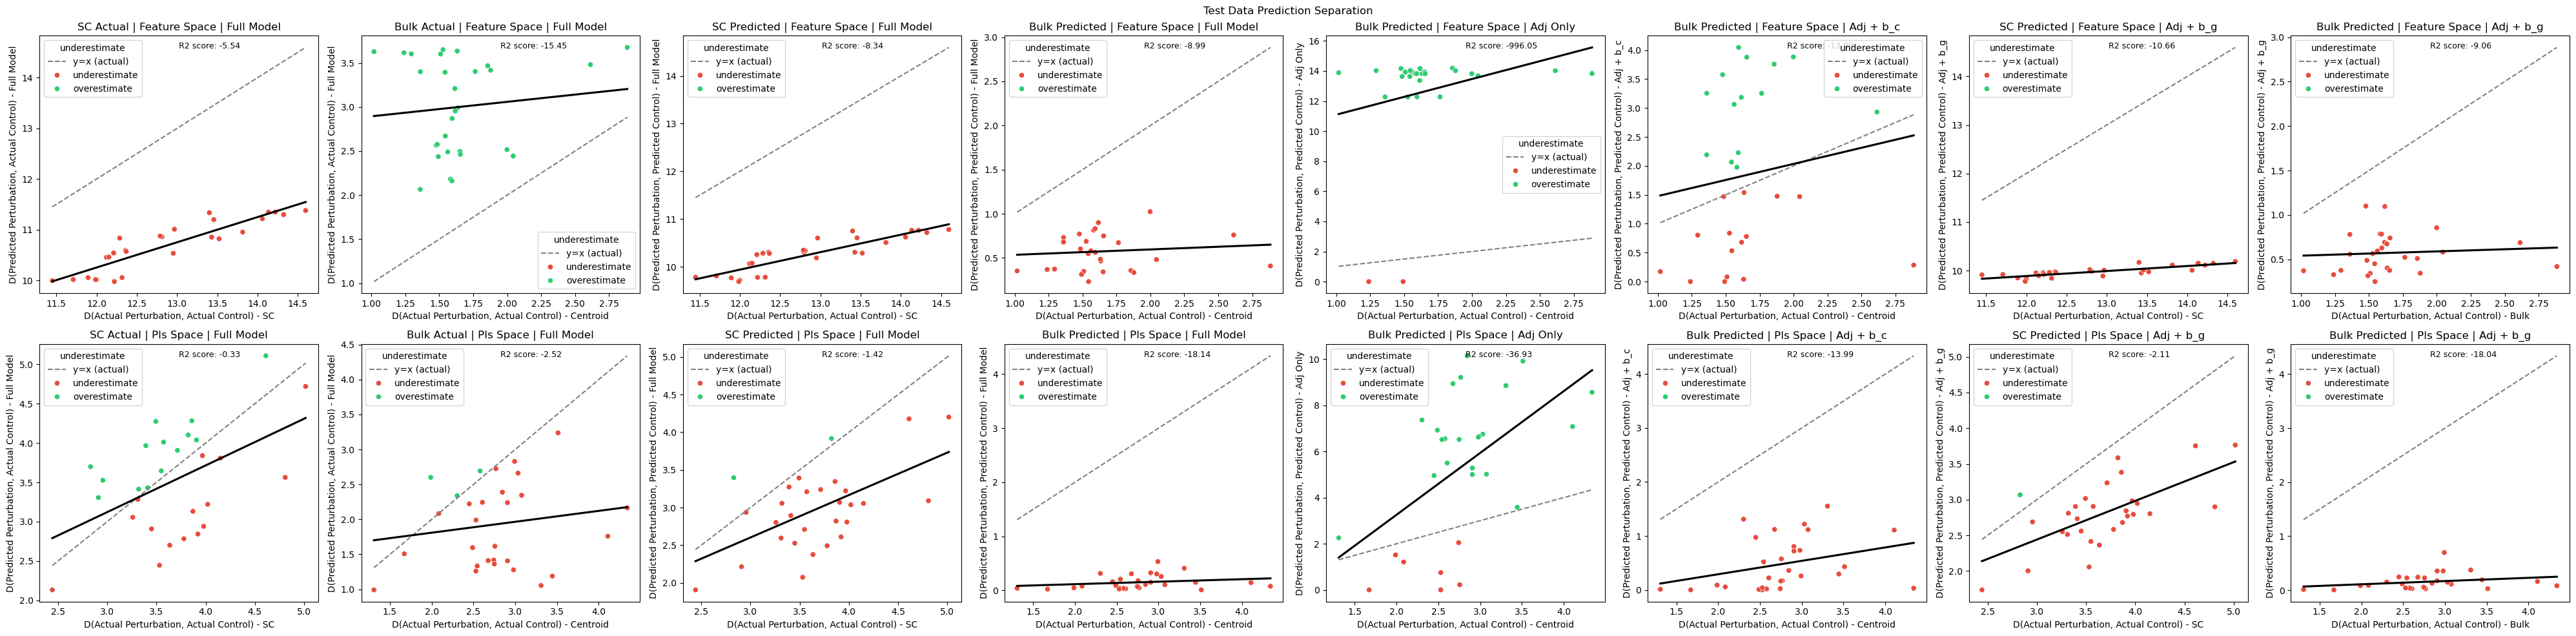

In [18]:
fig, ax = plt.subplots(ncols = 8, nrows = 2, figsize = (40, 10))

# sc actual
j = 0
pred_dist = 'pred_actual_dist'
for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components == 'full') & (dist_res.space == space)].copy()
    viz_df['underestimate'] = pd.Categorical((viz_df[pred_dist] < viz_df['actual_dist']).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    sns.lineplot(viz_df, x = 'actual_dist', y = 'actual_dist',  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = 'actual_dist', y = pred_dist, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = 'actual_dist', y = pred_dist,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df.actual_dist.values, viz_df[pred_dist].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Actual Control) - Full Model')
    ax[i,j].set_xlabel('D(Actual Perturbation, Actual Control) - SC')
    ax[i,j].set_title('SC Actual | {} Space | Full Model'.format(space.capitalize()))
    
    
# bulk actual
j = 1
pred_dist = 'pred_actual_dist'
included_components = 'full_bulk'
actual_dist = 'actual_dist_centroid'
for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components == included_components) & (dist_res.space == space)].copy()
    viz_df['underestimate'] = pd.Categorical((viz_df[pred_dist] < viz_df[actual_dist]).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    sns.lineplot(viz_df, x = actual_dist, y = actual_dist,  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = actual_dist, y = pred_dist, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = actual_dist, y = pred_dist,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df[actual_dist].values, viz_df[pred_dist].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Actual Control) - Full Model')
    ax[i,j].set_xlabel('D(Actual Perturbation, Actual Control) - Centroid')
    ax[i,j].set_title('Bulk Actual | {} Space | Full Model'.format(space.capitalize()))
    
    
# sc predicted
j = 2
pred_dist = 'pred_space_dist'
for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components == 'full') & (dist_res.space == space)].copy()
    viz_df['underestimate'] = pd.Categorical((viz_df[pred_dist] < viz_df['actual_dist']).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    sns.lineplot(viz_df, x = 'actual_dist', y = 'actual_dist',  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = 'actual_dist', y = pred_dist, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = 'actual_dist', y = pred_dist,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df.actual_dist.values, viz_df[pred_dist].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Predicted Control) - Full Model')
    ax[i,j].set_xlabel('D(Actual Perturbation, Actual Control) - SC')
    ax[i,j].set_title('SC Predicted | {} Space | Full Model'.format(space.capitalize()))
    
# bulk predicted  
j = 3
pred_dist = 'pred_space_dist'
included_components = 'full_bulk'
actual_dist = 'actual_dist_centroid'
for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components == included_components) & (dist_res.space == space)].copy()
    viz_df['underestimate'] = pd.Categorical((viz_df[pred_dist] < viz_df[actual_dist]).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    sns.lineplot(viz_df, x = actual_dist, y = actual_dist,  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = actual_dist, y = pred_dist, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = actual_dist, y = pred_dist,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df[actual_dist].values, viz_df[pred_dist].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Predicted Control) - Full Model')
    ax[i,j].set_xlabel('D(Actual Perturbation, Actual Control) - Centroid')
    ax[i,j].set_title('Bulk Predicted | {} Space | Full Model'.format(space.capitalize()))
    
# adj only collapse (relative to actual centroids distances) 
j = 4
pred_dist = 'pred_space_dist'
included_components = 'adj'
actual_dist = 'actual_dist_centroid'
for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components == included_components) & (dist_res.space == space)].copy()
    viz_df['underestimate'] = pd.Categorical((viz_df[pred_dist] < viz_df[actual_dist]).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    sns.lineplot(viz_df, x = actual_dist, y = actual_dist,  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = actual_dist, y = pred_dist, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = actual_dist, y = pred_dist,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df[actual_dist].values, viz_df[pred_dist].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Predicted Control) - Adj Only')
    ax[i,j].set_xlabel('D(Actual Perturbation, Actual Control) - Centroid')
    ax[i,j].set_title('Bulk Predicted | {} Space | Adj Only'.format(space.capitalize()))
    
    
j = 5
pred_dist = 'pred_space_dist'
included_components = 'adj^categorical_bias'
actual_dist = 'actual_dist_centroid'
for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components == included_components) & (dist_res.space == space)].copy()
    viz_df['underestimate'] = pd.Categorical((viz_df[pred_dist] < viz_df[actual_dist]).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    sns.lineplot(viz_df, x = actual_dist, y = actual_dist,  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = actual_dist, y = pred_dist, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = actual_dist, y = pred_dist,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df[actual_dist].values, viz_df[pred_dist].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Predicted Control) - Adj + b_c')
    ax[i,j].set_xlabel('D(Actual Perturbation, Actual Control) - Centroid')
    ax[i,j].set_title('Bulk Predicted | {} Space | Adj + b_c'.format(space.capitalize()))
    
    
j = 6
pred_dist = 'pred_space_dist'
included_components = 'adj^global_bias'
actual_dist = 'actual_dist'
for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components == included_components) & (dist_res.space == space)].copy()
    viz_df['underestimate'] = pd.Categorical((viz_df[pred_dist] < viz_df[actual_dist]).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    sns.lineplot(viz_df, x = actual_dist, y = actual_dist,  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = actual_dist, y = pred_dist, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = actual_dist, y = pred_dist,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df[actual_dist].values, viz_df[pred_dist].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Predicted Control) - Adj + b_g')
    ax[i,j].set_xlabel('D(Actual Perturbation, Actual Control) - SC')
    ax[i,j].set_title('SC Predicted | {} Space | Adj + b_g'.format(space.capitalize()))
    
    
j = 7
pred_dist = 'pred_space_dist'
included_components = 'adj^global_bias_bulk'
actual_dist = 'actual_dist_centroid'
for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components == included_components) & (dist_res.space == space)].copy()
    viz_df['underestimate'] = pd.Categorical((viz_df[pred_dist] < viz_df[actual_dist]).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    sns.lineplot(viz_df, x = actual_dist, y = actual_dist,  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = actual_dist, y = pred_dist, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = actual_dist, y = pred_dist,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df[actual_dist].values, viz_df[pred_dist].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Predicted Control) - Adj + b_g')
    ax[i,j].set_xlabel('D(Actual Perturbation, Actual Control) - Bulk')
    ax[i,j].set_title('Bulk Predicted | {} Space | Adj + b_g'.format(space.capitalize()))

fig.suptitle('Test Data Prediction Separation')
fig.tight_layout()
;

In [ ]:
fig, ax = plt.subplots(ncols = 3, nrows = 2, figsize = (15,10))


# categorial bias collapse in predicted space
j = 0
pred_dist = 'pred_space_dist'
comp_col = 'adj^categorical_bias'
for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components.isin(['adj', comp_col])) & 
                      (dist_res.space == space)].copy()[['included_components', 'condition', pred_dist]]
    
    viz_df = viz_df.pivot(index='condition', columns='included_components', values=pred_dist).reset_index(drop = True)
    viz_df['underestimate'] = pd.Categorical((viz_df[comp_col] < viz_df['adj']).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    
    sns.lineplot(viz_df, x = 'adj', y = 'adj',  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = 'adj', y = comp_col, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = 'adj', y = comp_col,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df.adj.values, viz_df[comp_col].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Predicted Control) - Adj + b_c')
    ax[i,j].set_xlabel('D(Predicted Perturbation, Predicted Control) - Adj')
    ax[i,j].set_title('Categorical Bias Collapse in Predictions | {} Space'.format(space.capitalize()))
    
    
# global bias collapse in predicted space
j = 1
pred_dist = 'pred_space_dist'
comp_col = 'adj^global_bias'

for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components.isin(['adj', comp_col])) & 
                      (dist_res.space == space)].copy()[['included_components', 'condition', pred_dist]]
    
    viz_df = viz_df.pivot(index='condition', columns='included_components', values=pred_dist).reset_index(drop = True)
    viz_df['underestimate'] = pd.Categorical((viz_df[comp_col] < viz_df['adj']).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    
    sns.lineplot(viz_df, x = 'adj', y = 'adj',  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = 'adj', y = comp_col, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = 'adj', y = comp_col,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df.adj.values, viz_df[comp_col].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Predicted Control) - Adj + b_g')
    ax[i,j].set_xlabel('D(Predicted Perturbation, Predicted Control) - Adj')
    ax[i,j].set_title('Global Bias Collapse in Predictions | {} Space'.format(space.capitalize()))
    
    
    
j = 2
pred_dist = 'pred_space_dist'
comp_col = 'adj^global_bias_bulk'

for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components.isin(['adj', comp_col])) & 
                      (dist_res.space == space)].copy()[['included_components', 'condition', pred_dist]]
    
    viz_df = viz_df.pivot(index='condition', columns='included_components', values=pred_dist).reset_index(drop = True)
    viz_df['underestimate'] = pd.Categorical((viz_df[comp_col] < viz_df['adj']).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    
    sns.lineplot(viz_df, x = 'adj', y = 'adj',  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = 'adj', y = comp_col, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = 'adj', y = comp_col,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df.adj.values, viz_df[comp_col].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Predicted Control) - Adj + b_g')
    ax[i,j].set_xlabel('D(Predicted Perturbation, Predicted Control) - Adj')
    ax[i,j].set_title('BULK Global Bias Collapse in Predictions | {} Space'.format(space.capitalize()))
    
fig.suptitle('Test Data Bias Collapse')
fig.tight_layout()
;

No harm regularization test

In [ ]:
# tf_adata_no_b = predictions_res['total_bias'].copy()
# tf_adata_no_bg = predictions_res['categorical_bias'].copy()

# tf_adata_no_b = tf_adata_no_b[tf_adata_no_b.obs.batch.isin(['predicted', 'predicted_ctrl'])]
# tf_adata_no_bg = tf_adata_no_bg[tf_adata_no_bg.obs.batch.isin(['predicted', 'predicted_ctrl'])]

# subs = []
# test = tf_adata_no_bg[tf_adata_no_bg.obs.batch == 'predicted_ctrl']
# for cl in test.obs.cell_line.unique():
#     test_sub = test[test.obs.cell_line == cl]
#     test_sub = test_sub[test_sub.obs.control_for == test_sub.obs.control_for.unique().tolist()[0]]
#     subs.append(test_sub)
# import anndata as ad
# test = ad.concat(subs)
# tf_adata_no_bg=ad.concat([tf_adata_no_bg[tf_adata_no_bg.obs.batch == 'predicted'], 
#            test])

# subs = []
# test = tf_adata_no_b[tf_adata_no_b.obs.batch == 'predicted_ctrl']
# for cl in test.obs.cell_line.unique():
#     test_sub = test[test.obs.cell_line == cl]
#     test_sub = test_sub[test_sub.obs.control_for == test_sub.obs.control_for.unique().tolist()[0]]
#     subs.append(test_sub)
# import anndata as ad
# test = ad.concat(subs)
# tf_adata_no_b=ad.concat([tf_adata_no_b[tf_adata_no_b.obs.batch == 'predicted'], 
#            test])


# for cond in tf_adata_no_b.obs.condition.unique():
#     cl, pert = cond.split('^')
    
#     if pert == 'DMSO_TF':
#         continue
        
#     ctrl_cond = cl + '^' 'DMSO_TF'
        
#     sub_bg = tf_adata_no_bg[tf_adata_no_bg.obs.condition.isin([cond, ctrl_cond])]
#     sub_b = tf_adata_no_b[tf_adata_no_b.obs.condition.isin([cond, ctrl_cond])]
    
    
#     b_pert = sub_b[sub_b.obs.drug == pert].X.toarray()
#     b_ctrl = sub_b[sub_b.obs.drug == 'DMSO_TF'].X.toarray()
#     b_dist = np.linalg.norm(b_pert - b_ctrl)
    
#     bg_pert = sub_bg[sub_bg.obs.drug == pert].X.toarray().mean(axis = 0)
#     bg_ctrl = sub_bg[sub_bg.obs.drug == 'DMSO_TF'].X.toarray().mean(axis = 0)
#     bg_dist = np.linalg.norm(bg_pert - bg_ctrl)
    
#     print('Adj only: {:2f}'.format(b_dist))
#     print('Adj + b_g: {:.2f}'.format(bg_dist))
#     print('-------------------------')

### 3.4 Train Predictions Full Forward Pass
Look at a subset of the train predictions without counterfactual to see whether there are generalization problems:

In [ ]:
remove_types = ['none',
                     ['adj', 'categorical_bias'],
                     ['adj', 'global_bias'],
                     'total_bias', 
                     'adj',
                     'categorical_bias',
                     'global_bias']

global_bias_removed = [['adj', 'global_bias'], 'global_bias', 'total_bias']
per_condition_embedding = True

In [ ]:
n_sub_train = 50
n_viz_train = 10
n_viz_train = min(n_viz_train, n_sub_train)

np.random.seed(seed)
train_conds_sub = np.random.choice([tc for tc in train_conds if tc.split('^')[1] != ctrl_pert], n_sub_train, replace = False)
tf_adata_sub = tf_adata[tf_adata.obs.condition.isin(train_conds_sub)].copy()

train_cells_sub = tf_adata_sub.obs_names

# necessary only because data was subsetted prior to training
train_cells_sub = list(set(train_cells_sub.intersection(trainer.X_train.index.tolist())))

ctrl_conds = sorted(set([tc.split('^')[0] + '^DMSO_TF' for tc in train_conds_sub]))  
mask = tf_adata.obs.loc[train_cells, 'condition'].isin(ctrl_conds).values
ctrl_cells = list(np.array(train_cells)[mask])


Get the PLS fits for the trainingin conditions:

In [ ]:
from tqdm import tqdm
pls_rank = tf_adata.uns['pls']['model_fit']['n_components']
pls_models_train = {}

for train_cond in tqdm(train_conds_sub):
    cell_line, pert = train_cond.split('^')
    tf_adata_sub, r2_df = ls.pls_da_pipeline(
        adata = tf_adata_all, # fit on full dataset
        pert_ids = [pert, ctrl_pert],
        cat_ids = cell_line,
        n_components = pls_rank, 
        pert_col = 'drug', 
        cat_col = 'cell_line', 
        separate_by = 'perturbation', 
        control_confounders = [], 
        covariate_associations = ['drug'],
        scale = False, # TF activity already Z-scored
        run_umap = False, 
        file_prefix = None, 
        verbose = True,
        seed = seed, 
        n_cores = n_cores
    )

    for k in ['pls_mod']: # ['encoder_y', '']:
        pls_models_train[train_cond] = {
            k: tf_adata_sub.uns['pls'][k]
        }
    pls_models_train[train_cond]['top_components_drug'] = ls.get_top_components(r2_df, top_components_cov = 'drug')

del tf_adata_sub


In [ ]:
train_predictions_res={}
for remove_type in remove_types:
    # get the prediction
    tf_adata_predicted = Tu.get_prediction(
        mod = mod,
        train_cells = train_cells_sub,
        test_cells = [], 
        tf_adata = tf_adata,
        cat_col = cat_col,
        pert_col = pert_col,
        ctrl_pert = 'DMSO_TF', 
        counterfactual = None,
        cat_counterfactual_map = None,
        remove_type = remove_type,
        return_bias = False, 
        max_cells = int(5e3), 
        return_full = False,
    )


    # CTRL: get the control condition predictions (training data with no counterfactual) as a comparison
    tf_adata_ctrl_predicted = Tu.get_prediction(
        mod = mod,
        train_cells = ctrl_cells,
        test_cells = [], 
        tf_adata = tf_adata,
        cat_col = cat_col,
        pert_col = pert_col,
        ctrl_pert = 'DMSO_TF', 
        counterfactual = None,
        cat_counterfactual_map = None,
        remove_type = remove_type,
        return_bias = False, 
        max_cells = int(5e3), 
        return_full = False,
    )
    

    # check lack of variance in non-generative predictions (no b_g) and merge
    if remove_type in global_bias_removed:
        tf_adata_predicted = Tu.merge_novar_predictions(tf_adata_predicted, remove_type, atol = 1e-4)
        # CTRL:
        tf_adata_ctrl_predicted = Tu.merge_novar_predictions(tf_adata_ctrl_predicted, remove_type, atol = 1e-4)

    # CTRL: merge the control predictions with the counterfactual ones
    tf_adata_predicted.obs_names = tf_adata_predicted.obs_names + '_predicted'
    tf_adata_ctrl_predicted.obs_names = tf_adata_ctrl_predicted.obs_names + '_predicted_ctrl'
    tf_adata_predicted = sc.concat([tf_adata_predicted, tf_adata_ctrl_predicted])

    # project into embedding (PLS for perturbation counterfactual, PCA otherwise) and combine with actual anndata
    tf_adata_merged = Tu.project_prediction(
        tf_adata_actual = tf_adata, 
        tf_adata_predicted = tf_adata_predicted, 
        linear_projection = 'pls', 
        per_condition_models = pls_models_train,
        ctrl_pert = 'DMSO_TF', # only needed for per_condition_models
        counterfactual = 'perturbation', 
        cat_counterfactual_map = cat_counterfactual_map, 
        project_umap = False, 
        merge = True
    )
    
    # CTRL: add control specification
    mask = [on.endswith('_predicted_ctrl') for on in tf_adata_merged.obs.barcode]
    tf_adata_merged.obs.loc[mask, 'batch'] = 'predicted_ctrl'

    remove_type_ = remove_type
    if type(remove_type) == list:
        remove_type_ = '^'.join(remove_type)    
    train_predictions_res[remove_type_] = tf_adata_merged
    
    

In [ ]:
global_bias_removed = ['adj^global_bias', 'global_bias', 'total_bias']

remaining_components = {'none': 'Full Model', 
                        'global_bias': 'Adj + Categorical Bias', 
                        'adj^global_bias': 'Categorical Bias Only',
                        'total_bias': 'Adjaceny Matirx Only',
                       'adj^categorical_bias': 'Global Bias Only', 
                       'adj': 'Total Bias', 
                       'categorical_bias': 'Adj + Global Bias', 
                       }


palette = sns.color_palette(["#2ca02c",  # Green
                             "#1f77b4",  # Blue
                             "#9467bd",  # Purple
                             "#d62728",  # Red
                            ])

other_palette = ['#7a6c5d', '#5a7081',  '#8a7c9d', '#a1a88b']


# visualization parameters
# add jitter if there is no perturbation effect when using the adjacency matrix without global bias
jitter_atol = 1e-3
jitter_scaler = 3e2 #(multiplies the atol)
pert_effect_expected = ['none', 'total_bias', 'categorical_bias', 'global_bias']
pert_effect_expected = set(pert_effect_expected).intersection(global_bias_removed)

# number of cells to visualize
n_min_scaler = 3
n_max_cells = 1e3

In [ ]:
ncols = len(remaining_components)
nrows = n_viz_train

fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows))

for j, (remove_type, keep_type) in enumerate(remaining_components.items()):
    
    
    tam = train_predictions_res[remove_type]
    
    md_predicted = tam.obs[tam.obs.batch == 'predicted']  
#     if sorted(tf_adata_predicted.condition.unique()) != sorted(train_conds_sub):
#         raise ValueError('Something went wrong in merging conditions')
    
    
    counterfactual_map = dict(zip(md_predicted.condition, md_predicted.condition.apply(lambda x: '^'.join([x.split('^')[0], ctrl_pert]))))


    
    for i, train_cond in enumerate(train_conds_sub[:n_viz_train]):
#         if i >= 2:
#             continue
        
        
        # ---------------PREPARE VARIABLES---------------
        
        test_cl, test_pert = train_cond.split('^')
        
        test_var = test_pert 
        ctrl_var = counterfactual_map[train_cond].split('^')[1]
        main_col = pert_col

        cats = [pert_col, 'batch']

        ortho_var = test_cl
        ortho_col = cat_col

        reduction_type = 'pls'


        category_order = [ctrl_var + '^' + 'actual',
                          test_var + '^' + 'actual',
                          ctrl_var + '^' + 'predicted_ctrl',
                          test_var + '^' + 'predicted'] 
        
        if per_condition_embedding:
            top_components = pls_models_train[train_cond]['top_components_' + pert_col]
        else:
            top_components = ['1', '2']

        #---------------FORMAT MAIN VISUALIZATION---------------
        actual_cells_mask = (tam.obs.batch == 'actual')
        test_mask = (tam.obs.condition == train_cond) # predictions and corresponding test data

        train_mask = (tam.obs.condition == counterfactual_map[train_cond])# & actual_cells_mask <-- without predicted_ctrl
        if per_condition_embedding:
            train_mask = train_mask & (tam.obs.control_for == test_var)

        tam_sub = tam[test_mask | train_mask, :].copy()

        # ############### subsetting to comparable no. of cells ###############
        # ############################################################
        tam_sub.obs.loc[
            (tam_sub.obs.batch == 'actual') & (tam_sub.obs[main_col] == ctrl_var),
            'batch'
        ] = 'actual_ctrl'

        if remove_type == 'none': # assuming this is first
            batch_counts = tam_sub.obs.batch.value_counts()
            max_viz_cells = min(n_min_scaler*batch_counts.min(), n_max_cells)

            if (batch_counts < max_viz_cells).all(): # instances where we made 3*.min() too big
                max_viz_cells = min(batch_counts.max(), n_max_cells)
        batch_counts = tam_sub.obs.batch.value_counts() # changes for the global bias removed scenarios


        viz_df_actual = Tu.adata_dimviz(adata = tam_sub[tam_sub.obs.batch == 'actual'], 
                              subset_size = min(batch_counts.actual, max_viz_cells), 
                              reduction_type = reduction_type, 
                              cats = cats, 
                              seed = 888)

        viz_df_actual_ctrl = Tu.adata_dimviz(adata = tam_sub[tam_sub.obs.batch == 'actual_ctrl'], 
                              subset_size = min(batch_counts.actual_ctrl, max_viz_cells), 
                              reduction_type = reduction_type, 
                              cats = cats, 
                              seed = 888)
        viz_df_actual_ctrl.batch = 'actual' # this labeling was only for subsetting
        viz_df_actual = pd.concat([viz_df_actual, viz_df_actual_ctrl])

        viz_df_predicted = Tu.adata_dimviz(adata = tam_sub[tam_sub.obs.batch == 'predicted'], 
                              subset_size = min(batch_counts.predicted, max_viz_cells), 
                              reduction_type = reduction_type, 
                              cats = cats, 
                              seed = 888)
        viz_df_predicted_ctrl = Tu.adata_dimviz(adata = tam_sub[tam_sub.obs.batch == 'predicted_ctrl'], 
                              subset_size = min(batch_counts.predicted_ctrl, max_viz_cells), 
                              reduction_type = reduction_type, 
                              cats = cats, 
                              seed = 888)
        # ############################################################


        if remove_type in global_bias_removed and (viz_df_predicted.shape[0] != 1 
                                                   or viz_df_predicted_ctrl.shape[0] != 1):
            raise ValueError('Unexpected multiple values for no global bias')
        else:
            coords = viz_df_predicted.iloc[0, :2].tolist()
            coords_ctrl = viz_df_predicted_ctrl.iloc[0, :2].tolist()
            
        # add jitter if there is no perturbation effect  
        jitter_label = None
        ctrl_vals = viz_df_predicted_ctrl.values[0][:-2].astype('float64').copy()
        if remove_type in pert_effect_expected: 
            if np.allclose(viz_df_predicted.values[0][:-2].astype('float64'), 
                        ctrl_vals, 
                        atol = jitter_atol, rtol = 1e-3):
                # add jitter
                ctrl_vals += np.random.uniform(-jitter_atol*jitter_scaler, jitter_atol*jitter_scaler, ctrl_vals.shape)
                viz_df_predicted_ctrl.iloc[0, :-2] = ctrl_vals

                jitter_label = 'WARNING: Jitter added - No perturbation separation'
        elif remove_type == 'adj^global_bias':
            if np.allclose(viz_df_predicted.values[0][:-2].astype('float64'), 
                            ctrl_vals, 
                            atol = 1e-4, rtol = 1e-4):
                jitter_label = 'Minor jitter added for visualization' # expected no difference
            else:
                jitter_label = 'WARNING: Jitter added - values are NOT the same across {}' # unexpected difference
            ctrl_vals += np.random.uniform(-jitter_atol*(jitter_scaler/3), jitter_atol*(jitter_scaler/3), ctrl_vals.shape)
            viz_df_predicted_ctrl.iloc[0, :-2] = ctrl_vals

            
        viz_df_predicted = pd.concat([viz_df_predicted, viz_df_predicted_ctrl], axis = 0)
        viz_df_predicted = viz_df_predicted.sample(frac=1.0, random_state=seed)
        viz_df = pd.concat([viz_df_actual, viz_df_predicted], axis = 0).reset_index(drop = True)

        viz_df['condition'] = viz_df[cats].apply(lambda x: '^'.join(x), axis = 1)


        co_map  = dict(zip(
            category_order, 
            [
                'Observed Under: ' + ctrl_var + ' (Train)', 
                'OOD Condition: ' + test_var + ' (Test)', 
                'Control Prediction: ' + ctrl_var + '\n(Train, no counterfactual)',
                'Counterfactual Prediction: ' + test_var + '\n (from ' + ctrl_var +  ')', 
            ]

        ))

        viz_df.condition = pd.Categorical(
            viz_df.condition,
            categories = category_order,
            ordered = True).map(co_map, na_action = 'ignore')

        viz_df.batch = viz_df.batch.replace('predicted_ctrl', 'predicted')
        viz_df.batch = pd.Categorical(viz_df.batch, 
                                     categories = ['actual', 'predicted'], 
                                     ordered=True).map({'actual': 'Actual', 'predicted': 'Predicted'}, na_action = 'ignore')



        # ---------------FORMAT BACKGROUND (OTHER CELLS) VISUALIZATION--------------- 
        if not per_condition_embedding:
            # all other cells (not filtered for train vs test)
            om_base = actual_cells_mask & ~(tam.obs.condition.isin([train_cond, counterfactual_map[train_cond]]))


            other_counterfactual = (tam.obs[main_col] == test_pert) # same perturbation as test but not same cell line
            other_ctrl = (tam.obs[main_col] == ctrl_var) # same perturbation as ctrl but not same cell line
            other_ortho = (tam.obs[ortho_col] == ortho_var) # same cell line but not in ctrl/pert conditions
            other_remaining = ~(other_counterfactual) & ~(other_ctrl) & ~(other_ortho) # remaining

            other_masks = [other_counterfactual, other_ctrl, other_ortho, other_remaining]
            om_names = [
                'Other: {} (not {})'.format(test_var, ortho_var), 
                'Other: {} (not {})'.format(ctrl_var, ortho_var), 
                'Other: {} (not {} or {})'.format(ortho_var, test_var, ctrl_var), 
                'All Other Cells'
            ]

            # ONLY show other cells #3
            other_idx = 2
            other_masks = [other_masks[other_idx]]
            om_names = [om_names[other_idx]]

            om_map =  dict(zip(om_names, other_masks))

            vdo = []
            for omn, om in om_map.items():
                viz_df_other = Tu.adata_dimviz(adata = tam[om & om_base, :], 
                                  subset_size = int(1e3), 
                                  reduction_type = reduction_type, 
                                  cats = ['condition'], # subsetting by condition
                                  seed = 888)
                viz_df_other.condition = omn
                vdo.append(viz_df_other)

            viz_df_other = pd.concat(vdo, ignore_index = True).sample(frac = 1, 
                                                                      random_state = seed).reset_index(drop = True)
            viz_df_other.condition = pd.Categorical(viz_df_other.condition, 
                                                   categories = om_names, 
                                                   ordered = True)

        #---------------VISUALIZE BACKGROUND---------------

            sns.scatterplot(
                data = viz_df_other, 
                x = Tu.reduction_type_map[reduction_type].upper() + top_components[0], 
                y = Tu.reduction_type_map[reduction_type].upper() + top_components[1],
                hue = 'condition', palette = [other_palette[other_idx]],  
                marker = 'o', s = 10,
                ax = ax[i,j]
            )

        # ---------------VISUALIZE MAIN---------------
        if remove_type in global_bias_removed:
            viz_df_actual = viz_df[viz_df.batch == 'Actual'].copy()
            viz_df_predicted = viz_df[viz_df.batch == 'Predicted'].copy()

            viz_df_actual.condition = viz_df_actual.condition.cat.remove_unused_categories()
            viz_df_predicted.condition = viz_df_predicted.condition.astype(str)

            for viz_df in [viz_df_actual, viz_df_predicted]:
                viz_df.batch = viz_df.batch.astype(str)

            viz_df_predicted_ctrl = viz_df_predicted[viz_df_predicted.condition == co_map[ctrl_var + '^predicted_ctrl']]
            viz_df_predicted = viz_df_predicted[viz_df_predicted.condition != co_map[ctrl_var + '^predicted_ctrl']]


            sns.scatterplot(
                data = viz_df_actual, 
                x = Tu.reduction_type_map[reduction_type].upper() + top_components[0], 
                y = Tu.reduction_type_map[reduction_type].upper() + top_components[1], 
                hue = 'condition', palette = palette[:2], 
                marker = 'o',
                ax = ax[i,j]
            )


            sns.scatterplot(
                data = viz_df_predicted, 
                x = Tu.reduction_type_map[reduction_type].upper() + top_components[0], 
                y = Tu.reduction_type_map[reduction_type].upper() + top_components[1],
                color = palette[-1],
                marker = '^', s = 200,
                ax = ax[i,j]
            )

            sns.scatterplot(
                data = viz_df_predicted_ctrl, 
                x = Tu.reduction_type_map[reduction_type].upper() + top_components[0], 
                y = Tu.reduction_type_map[reduction_type].upper() + top_components[1],
                color = palette[2],
                marker = '^', s = 200,
                ax = ax[i,j]
            )


            ax[i,j].annotate('Prediction Coordinates: {:.2f}, {:.2f}'.format(coords[0], coords[1]), 
                       xy = (0.4, 0.95), xycoords='axes fraction', fontsize = 9)

            ax[i,j].annotate('Ctrl Prediction Coordinates: {:.2f}, {:.2f}'.format(coords_ctrl[0], coords_ctrl[1]), 
                       xy = (0.35, 0.9), xycoords='axes fraction', fontsize = 9)


        else:

            sns.scatterplot(
                data = viz_df, 
                x = Tu.reduction_type_map[reduction_type].upper() + top_components[0], 
                y = Tu.reduction_type_map[reduction_type].upper() + top_components[1], 
                hue = 'condition', palette = palette,  
                style = 'batch',  markers = {'Actual': 'o', 'Predicted': '^'}, 
                ax = ax[i,j]
            )

            handles, labels = ax[i,j].get_legend_handles_labels()
            labels = [lab if lab not in ['condition', 'batch'] else None for lab in labels]
            ax[i,j].legend(handles, labels, 
                     loc = 'upper left', 
                     bbox_to_anchor=(-0.8, 0.975),
                      fontsize = 8, 
                     ncol = 1)
            
        if jitter_label is not None:
            if 'WARNING' in jitter_label:
                color = 'red'
            else:
                color = 'black'
            ax[i,j].annotate(jitter_label, xy = (0.05, 0.85), xycoords='axes fraction', fontsize = 9, 
                            color = color)

        ax[i,j].set_title(keep_type)
        if j != 0:
            ax[i,j].get_legend().remove()

fig.tight_layout()
;



Same regularization check on the training data that will actually be used:

In [ ]:
tam_full = train_predictions_res['none'].copy()

train_conds = {c for c in tam_full.obs.condition if c.split('^')[1] != ctrl_pert}

tam_actual = {}
actual_mask = (tam_full.obs.batch == 'actual')
for cond in train_conds:
    cl, pert = cond.split('^')
    cl_mask = (tam_full.obs.cell_line == cl)
    pert_mask = (tam_full.obs.drug == pert)
    
    ctrl_mask = (tam_full.obs.drug == ctrl_pert) & (tam_full.obs.control_for == pert)
    
    tam_actual_ctrl = tam_full[cl_mask & actual_mask & ctrl_mask]
    tam_actual_pert = tam_full[cl_mask & actual_mask & pert_mask]
    
    tam_actual[cond] = {'ctrl': tam_actual_ctrl, 'pert': tam_actual_pert}
    
    
# from remove type to included type
tams = {
    'full': train_predictions_res['none'].copy(), 
    'adj': train_predictions_res['total_bias'].copy(), 
    'adj^categorical_bias': train_predictions_res['global_bias'].copy(), 
    'adj^global_bias': train_predictions_res['categorical_bias'].copy()
}

dist_res = {
    'included_components': [], 
    'condition': [], 
    'space': [], 
    'pred_space_dist': [], 
    'pred_actual_dist': [], 
    'actual_dist': [],
    'actual_dist_centroid': []
}

for fp, tam in tams.items():
    for cond in train_conds:
        for space in ['feature', 'PLS']:
    
            res  = get_distances(tam = tam, cond = cond, space = space, 
                                 tam_actual = tam_actual, pls_models = pls_models_train)
            pred_space_dist, pred_actual_dist, actual_dist, actual_dist_centroid = res

            dist_res['included_components'] += [fp]
            dist_res['condition'] += [cond]
            dist_res['space'] += [space]
            dist_res['pred_space_dist'] += [pred_space_dist]
            dist_res['pred_actual_dist'] += [pred_actual_dist]
            dist_res['actual_dist'] += [actual_dist]
            dist_res['actual_dist_centroid'] += [actual_dist_centroid]
        
        
# also get bulk distances 
get_bulk = ['adj^global_bias', 'full']
for fp, tam in tams.items():
    if fp not in get_bulk:
        continue
    for cond in train_conds:
        for space in ['feature', 'PLS']:

            res  = get_distances(tam = tam, cond = cond, space = space, 
                                 tam_actual = tam_actual, pls_models = pls_models_train, bulk_pred_pert=True)
            pred_space_dist, pred_actual_dist, actual_dist, actual_dist_centroid = res

            dist_res['included_components'] += [fp + '_bulk']
            dist_res['condition'] += [cond]
            dist_res['space'] += [space]
            dist_res['pred_space_dist'] += [pred_space_dist]
            dist_res['pred_actual_dist'] += [pred_actual_dist]
            dist_res['actual_dist'] += [actual_dist]
            dist_res['actual_dist_centroid'] += [actual_dist_centroid]


dist_res = pd.DataFrame(dist_res)

In [ ]:
fig, ax = plt.subplots(ncols = 8, nrows = 2, figsize = (40, 10))

# sc actual
j = 0
pred_dist = 'pred_actual_dist'
for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components == 'full') & (dist_res.space == space)].copy()
    viz_df['underestimate'] = pd.Categorical((viz_df[pred_dist] < viz_df['actual_dist']).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    sns.lineplot(viz_df, x = 'actual_dist', y = 'actual_dist',  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = 'actual_dist', y = pred_dist, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = 'actual_dist', y = pred_dist,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df.actual_dist.values, viz_df[pred_dist].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Actual Control) - Full Model')
    ax[i,j].set_xlabel('D(Actual Perturbation, Actual Control) - SC')
    ax[i,j].set_title('SC Actual | {} Space | Full Model'.format(space.capitalize()))
    
# bulk actual    
j = 1
pred_dist = 'pred_actual_dist'
included_components = 'full_bulk'
actual_dist = 'actual_dist_centroid'
for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components == included_components) & (dist_res.space == space)].copy()
    viz_df['underestimate'] = pd.Categorical((viz_df[pred_dist] < viz_df[actual_dist]).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    sns.lineplot(viz_df, x = actual_dist, y = actual_dist,  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = actual_dist, y = pred_dist, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = actual_dist, y = pred_dist,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df[actual_dist].values, viz_df[pred_dist].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Actual Control) - Full Model')
    ax[i,j].set_xlabel('D(Actual Perturbation, Actual Control) - Centroid')
    ax[i,j].set_title('Bulk Actual | {} Space | Full Model'.format(space.capitalize()))
    
    
# sc predicted
j = 2
pred_dist = 'pred_space_dist'
for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components == 'full') & (dist_res.space == space)].copy()
    viz_df['underestimate'] = pd.Categorical((viz_df[pred_dist] < viz_df['actual_dist']).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    sns.lineplot(viz_df, x = 'actual_dist', y = 'actual_dist',  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = 'actual_dist', y = pred_dist, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = 'actual_dist', y = pred_dist,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df.actual_dist.values, viz_df[pred_dist].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Predicted Control) - Full Model')
    ax[i,j].set_xlabel('D(Actual Perturbation, Actual Control) - SC')
    ax[i,j].set_title('SC Predicted | {} Space | Full Model'.format(space.capitalize()))
    
    
# bulk predicted  
j = 3
pred_dist = 'pred_space_dist'
included_components = 'full_bulk'
actual_dist = 'actual_dist_centroid'
for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components == included_components) & (dist_res.space == space)].copy()
    viz_df['underestimate'] = pd.Categorical((viz_df[pred_dist] < viz_df[actual_dist]).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    sns.lineplot(viz_df, x = actual_dist, y = actual_dist,  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = actual_dist, y = pred_dist, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = actual_dist, y = pred_dist,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df[actual_dist].values, viz_df[pred_dist].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Predicted Control) - Full Model')
    ax[i,j].set_xlabel('D(Actual Perturbation, Actual Control) - Centroid')
    ax[i,j].set_title('Bulk Predicted | {} Space | Full Model'.format(space.capitalize()))
    
# adj only collapse (relative to actual centroids distances) 
j = 4
pred_dist = 'pred_space_dist'
included_components = 'adj'
actual_dist = 'actual_dist_centroid'
for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components == included_components) & (dist_res.space == space)].copy()
    viz_df['underestimate'] = pd.Categorical((viz_df[pred_dist] < viz_df[actual_dist]).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    sns.lineplot(viz_df, x = actual_dist, y = actual_dist,  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = actual_dist, y = pred_dist, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = actual_dist, y = pred_dist,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df[actual_dist].values, viz_df[pred_dist].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Predicted Control) - Adj Only')
    ax[i,j].set_xlabel('D(Actual Perturbation, Actual Control) - Centroid')
    ax[i,j].set_title('Bulk Predicted | {} Space | Adj Only'.format(space.capitalize()))
    
    
j = 5
pred_dist = 'pred_space_dist'
included_components = 'adj^categorical_bias'
actual_dist = 'actual_dist_centroid'
for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components == included_components) & (dist_res.space == space)].copy()
    viz_df['underestimate'] = pd.Categorical((viz_df[pred_dist] < viz_df[actual_dist]).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    sns.lineplot(viz_df, x = actual_dist, y = actual_dist,  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = actual_dist, y = pred_dist, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = actual_dist, y = pred_dist,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df[actual_dist].values, viz_df[pred_dist].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Predicted Control) - Adj + b_c')
    ax[i,j].set_xlabel('D(Actual Perturbation, Actual Control) - Centroid')
    ax[i,j].set_title('Bulk Predicted | {} Space | Adj + b_c'.format(space.capitalize()))
    
    
j = 6
pred_dist = 'pred_space_dist'
included_components = 'adj^global_bias'
actual_dist = 'actual_dist'
for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components == included_components) & (dist_res.space == space)].copy()
    viz_df['underestimate'] = pd.Categorical((viz_df[pred_dist] < viz_df[actual_dist]).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    sns.lineplot(viz_df, x = actual_dist, y = actual_dist,  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = actual_dist, y = pred_dist, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = actual_dist, y = pred_dist,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df[actual_dist].values, viz_df[pred_dist].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Predicted Control) - Adj + b_g')
    ax[i,j].set_xlabel('D(Actual Perturbation, Actual Control) - SC')
    ax[i,j].set_title('SC Predicted | {} Space | Adj + b_g'.format(space.capitalize()))
    
    
j = 7
pred_dist = 'pred_space_dist'
included_components = 'adj^global_bias_bulk'
actual_dist = 'actual_dist_centroid'
for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components == included_components) & (dist_res.space == space)].copy()
    viz_df['underestimate'] = pd.Categorical((viz_df[pred_dist] < viz_df[actual_dist]).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    sns.lineplot(viz_df, x = actual_dist, y = actual_dist,  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = actual_dist, y = pred_dist, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = actual_dist, y = pred_dist,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df[actual_dist].values, viz_df[pred_dist].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Predicted Control) - Adj + b_g')
    ax[i,j].set_xlabel('D(Actual Perturbation, Actual Control) - Bulk')
    ax[i,j].set_title('Bulk Predicted | {} Space | Adj + b_g'.format(space.capitalize()))

fig.suptitle('Train Data Prediction Separation')
fig.tight_layout()
;

In [ ]:
fig, ax = plt.subplots(ncols = 3, nrows = 2, figsize = (15,10))


# categorial bias collapse in predicted space
j = 0
pred_dist = 'pred_space_dist'
comp_col = 'adj^categorical_bias'
for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components.isin(['adj', comp_col])) & 
                      (dist_res.space == space)].copy()[['included_components', 'condition', pred_dist]]
    
    viz_df = viz_df.pivot(index='condition', columns='included_components', values=pred_dist).reset_index(drop = True)
    viz_df['underestimate'] = pd.Categorical((viz_df[comp_col] < viz_df['adj']).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    
    sns.lineplot(viz_df, x = 'adj', y = 'adj',  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = 'adj', y = comp_col, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = 'adj', y = comp_col,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df.adj.values, viz_df[comp_col].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Predicted Control) - Adj + b_c')
    ax[i,j].set_xlabel('D(Predicted Perturbation, Predicted Control) - Adj')
    ax[i,j].set_title('Categorical Bias Collapse in Predictions | {} Space'.format(space.capitalize()))
    
    
# global bias collapse in predicted space
j = 1
pred_dist = 'pred_space_dist'
comp_col = 'adj^global_bias'

for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components.isin(['adj', comp_col])) & 
                      (dist_res.space == space)].copy()[['included_components', 'condition', pred_dist]]
    
    viz_df = viz_df.pivot(index='condition', columns='included_components', values=pred_dist).reset_index(drop = True)
    viz_df['underestimate'] = pd.Categorical((viz_df[comp_col] < viz_df['adj']).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    
    sns.lineplot(viz_df, x = 'adj', y = 'adj',  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = 'adj', y = comp_col, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = 'adj', y = comp_col,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df.adj.values, viz_df[comp_col].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Predicted Control) - Adj + b_g')
    ax[i,j].set_xlabel('D(Predicted Perturbation, Predicted Control) - Adj')
    ax[i,j].set_title('Global Bias Collapse in Predictions | {} Space'.format(space.capitalize()))
    
    
    
j = 2
pred_dist = 'pred_space_dist'
comp_col = 'adj^global_bias_bulk'

for (i, space) in enumerate(['feature', 'PLS']):
    viz_df = dist_res[(dist_res.included_components.isin(['adj', comp_col])) & 
                      (dist_res.space == space)].copy()[['included_components', 'condition', pred_dist]]
    
    viz_df = viz_df.pivot(index='condition', columns='included_components', values=pred_dist).reset_index(drop = True)
    viz_df['underestimate'] = pd.Categorical((viz_df[comp_col] < viz_df['adj']).copy(), 
                                         categories = [True, False], 
                                         ordered = True)
    viz_df.underestimate = viz_df.underestimate.map({True: 'underestimate', False: 'overestimate'})
    
    
    sns.lineplot(viz_df, x = 'adj', y = 'adj',  
            linestyle = '--', color = 'gray', label = 'y=x (actual)', ax = ax[i,j])
    
    sns.scatterplot(viz_df, x = 'adj', y = comp_col, hue = 'underestimate', 
               palette = {'underestimate': "#e74c3c", 'overestimate': "#2ecc71"}, ax = ax[i,j])
    
    sns.regplot(viz_df, x = 'adj', y = comp_col,  
           scatter = False, fit_reg = True, lowess = False, ci = None, color = 'black', 
            label = 'Regression Fit', ax = ax[i,j])
    
    r2_score_ = sklearn.metrics.r2_score(viz_df.adj.values, viz_df[comp_col].values)
    
    ax[i,j].annotate('R2 score: {:.2f}'.format(r2_score_), 
               xy = (0.5, 0.95), xycoords='axes fraction', fontsize = 9)
    
    ax[i,j].set_ylabel('D(Predicted Perturbation, Predicted Control) - Adj + b_g')
    ax[i,j].set_xlabel('D(Predicted Perturbation, Predicted Control) - Adj')
    ax[i,j].set_title('BULK Global Bias Collapse in Predictions | {} Space'.format(space.capitalize()))
    
fig.suptitle('Train Data Bias Collapse')
fig.tight_layout()
;

# 4. Metrics

We will assess our results using X metrics. DE and distance-based metrics are analogous to those from the [Virtual Cell Challenge](https://www.cell.com/cell/fulltext/S0092-8674(25)00675-0). Rank-based metric from [Perturbench](https://arxiv.org/abs/2408.10609) is also employed by the Virtual Cell Challenge. 

## 4.1 Univariate Differential TF Activity

Here, we assess model predictions by their ability to univariately capture differential features as compared to the counterfactual condition that things were predicted from. This 1) captures biological accuracy and 2) demonstrated capability of the model for adversarial removal and putting that information back in.

 To measure the reproducibility of DE, we use the CATplot from [svaseq](https://doi.org/10.1093/nar/gku864).
We rank-order DE genes then calculate either the Jaccard index or DE score as described by the virtual cell challenge [here](https://virtualcellchallenge.org/evaluation) as our metric of concordance. We separately assess positively and negatively differentially expressed genes.

For concordance, we filter TFs with an FDR>0.1. If we set a cliffs delta filter (for "negligible"), we rank order by the effect size. Otherwise, we rank order by significance. We calculate the concordance across all TFs that pass this threshold, to the rank of the result with fewer total TFs that passed the threshold. 

Get a sense of the subsampling size if using or not:

In [ ]:
tam = predictions_res['none']
tf_adata_predicted = tam[tam.obs.batch == 'predicted', :].copy()
tf_adata_predicted.obs.condition.value_counts()

In [ ]:
from scLEMBAS.metrics import differential_expression as de
print('Begin DE testing: ')
de_res = {}
for test_cond in test_conds:
    de_res[test_cond] = de.concordance_pipeline(
        tf_adata_actual = tf_adata, 
        tf_adata_predicted = tf_adata_predicted, 
        test_condition = (test_cond.split('^')[0], test_cond.split('^')[1]), 
        pert_col = 'drug', 
        cat_col = 'cell_line', 
        ctrl_var = 'DMSO_TF', 
        counterfactual = 'perturbation', 
        n_subsample = None, # TODO: change this -- will need to balance with permutation for compute time
        n_permutation = 100, # TODO: increase this
        alpha = 0.05, 
        rank_by = 'effect_size', 
        concordance_metric = 'jaccard', 
        seed = 888
    )


In [ ]:
# some formatting
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
    cdf = []
    for test_cond, res in de_res.items():

        pos_concordance, neg_concordance, pos_concordance_rand, neg_concordance_rand = res
        for col in range(pos_concordance_rand.shape[1] - pos_concordance.shape[1]):
            pos_concordance[[pos_concordance.shape[1]]] = np.nan
            neg_concordance[[neg_concordance.shape[1]]] = np.nan

        pos_concordance['direction'] = 'positive'
        pos_concordance['type'] = 'real'


        neg_concordance['direction'] = 'negative'
        neg_concordance['type'] = 'real'

        pos_concordance_rand['direction'] = 'positive'
        pos_concordance_rand['type'] = 'random'

        neg_concordance_rand['direction'] = 'negative'
        neg_concordance_rand['type'] = 'random'

        concordance_df = pd.concat([pos_concordance, neg_concordance, pos_concordance_rand, neg_concordance_rand], 
                 axis = 0, ignore_index = False)
        concordance_df.reset_index(inplace = True)

        concordance_df['test_cond'] = test_cond

        cdf.append(concordance_df)

    concordance_df = pd.concat(cdf)


In [ ]:
# ncols = concordance_df.test_cond.nunique()
# nrows = 2
# fig, ax = plt.subplots(ncols = ncols, 
#                        nrows = nrows, 
#                        figsize = (ncols * 4.1, nrows *4.1))

# palette = [sns.color_palette()[0], sns.color_palette()[3]]

# for (j, test_cond) in enumerate(concordance_df.test_cond.unique()):
#     viz_df_ = concordance_df[concordance_df.test_cond == test_cond].drop(columns = 'test_cond')
#     for (i, direction) in enumerate(['positive', 'negative']):
#         viz_df = viz_df_[viz_df_.direction == direction].drop(columns = 'direction')

#         viz_df = pd.melt(viz_df, id_vars = ['rank', 'type'], value_name='concordance')

#         for (col_idx, calc_type) in enumerate(['real', 'random']): 
#             # smooth across iterations
#             sns.regplot(viz_df[viz_df['type'] == calc_type], ci=None, scatter = False, 
#                         x = 'rank', y = 'concordance', color = palette[col_idx], ax = ax[i,j], 
#                        label = calc_type.capitalize())
        
#         ax[i,j].set_ylabel(None)
#         ax[i,j].set_xlabel(None)
        
#         if j == 0: 
#             ax[i,j].set_ylabel('DE Concordance (Jaccard Index)')
#         if i == (nrows - 1):
#             ax[i,j].set_xlabel('Feature Rank')
#         if i == 0 and j == 0:
#             ax[i,j].legend()
#         if i == 0:
#             ax[i,j].set_title(test_cond)
#         if j == (ncols -1):
#             ax[i,j].set_ylabel('Effect Size Direction: {}'.format(direction.capitalize()))
#             ax[i,j].yaxis.set_label_position("right")
            
# fig.tight_layout()
# ;
                                

In [ ]:
n_cols_max = 5
palette = [sns.color_palette()[0], sns.color_palette()[3]]
conds = concordance_df.test_cond.unique().tolist()

n_blocks = math.ceil(len(conds) / n_cols_max)
fig = plt.figure(figsize=(4.1*n_cols_max, 4.1*(n_blocks*2)))

# Big gap between condition blocks:
outer = fig.add_gridspec(n_blocks, 1, hspace=0.15)  # ← enlarge/reduce inter-block spacing here

for b in range(n_blocks):
    batch = conds[b*n_cols_max:(b+1)*n_cols_max]
    # Tight gap within the 2 rows of the same condition:
    inner = outer[b].subgridspec(2, n_cols_max, hspace=0.1)  
    ax = inner.subplots()  # shape (2, n_cols_max)

    for j, test_cond in enumerate(batch):
        for i, direction in enumerate(['positive', 'negative']):
            viz_df_ = concordance_df[concordance_df.test_cond == test_cond].drop(columns='test_cond')
            viz_df = viz_df_[viz_df_.direction == direction].drop(columns='direction')
            viz_df = pd.melt(viz_df, id_vars=['rank', 'type'], value_name='concordance')

            for k, calc_type in enumerate(['real', 'random']):
                sns.regplot(
                    viz_df[viz_df['type'] == calc_type],
                    x='rank', y='concordance',
                    ci=None, scatter=False,
                    color=palette[k],
                    ax=ax[i, j],
                    lowess = True, 
                    seed = seed, 
                    label=calc_type.capitalize()
                )

            ax[i, j].set_ylabel(None)
            ax[i, j].set_xlabel(None)

            if j == 0:
                ax[i, j].set_ylabel('DE Concordance (Jaccard Index)')
            if i == 1:
                ax[i, j].set_xlabel('Feature Rank')
            if b == 0 and i == 0 and j == 0:
                ax[i, j].legend()
            if i == 0:
                ax[i, j].set_title(test_cond)
            if j == (len(batch) - 1):
                ax[i, j].set_ylabel(f'Effect Size Direction: {direction.capitalize()}')
                ax[i, j].yaxis.set_label_position("right")

    # remove unused axes in the last block if batch shorter than n_cols_max
    for j in range(len(batch), n_cols_max):
        for i in [0, 1]:
            fig.delaxes(ax[i, j])
fig.tight_layout()
;


## 4.2 Rank-based Metric

In [ ]:
from scLEMBAS.metrics.distances import rank_score


import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
tam = predictions_res['none']
tf_adata_predicted = tam[tam.obs.batch == 'predicted', :].copy()
rank_score_average, rank_scores = rank_score(tf_adata_actual = tf_adata.copy(), 
                                                   tf_adata_predicted = tf_adata_predicted, 
                                                   pert_col = 'drug', 
                                                   distance_metric = 'manhattan', 
                                                  )

print('The average rank score is {:.3f}'.format(rank_score_average))


In [ ]:
fig, ax = plt.subplots(figsize=(10,5))

viz_df = pd.DataFrame(pd.Series(rank_scores), columns = ['rank_score']).reset_index(drop = False, names = 'perturbation')
viz_df.sort_values(by = 'rank_score', ascending = False, inplace = True)

sns.scatterplot(
    data=viz_df,
    x="perturbation",
    y="rank_score",
    ax=ax,
    zorder=3
)
ymin, ymax = ax.get_ylim()

ax.vlines(
    x=viz_df["perturbation"],
    ymin=0,
    ymax=viz_df["rank_score"],
    colors="gray",
    linestyles="dashed",
    zorder=1
)

xmin, xmax = ax.get_xlim()

ax.hlines(
    y=rank_score_average,
    xmin=xmin,
    xmax=xmax,
    colors="black",
    label = 'Average Rank Score',
    linewidth = 0.5, 
    zorder = 2
)

ax.hlines(
    y=0.5,
    xmin=xmin,
    xmax=xmax,
    colors="red",
    label = 'Expected Random Score',
    linewidth = 0.5, 
    zorder = 2
)

ax.set_xlim(xmin, xmax)
if ymin > 0.5:
    ymin = 0.45
    ymax *= 1.05
ax.set_ylim(ymin, ymax)

ax.set_ylabel("Rank Score")
ax.set_xlabel("Perturbation")

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

;


To understand the extendt this is driven simply by cell line variance, let's see how many cell lines each perturbation maps to. If the ones that only have one cell line associated are the ones with the highest rank scores, this may simply be the model capturing cell line and not perturbation variance:

In [ ]:
from collections import defaultdict
counts = defaultdict(set)
for entry in tf_adata_predicted.obs.condition.unique():
    celltype, pert = entry.split("^")
    counts[pert].add(celltype)

counts = {pert: len(celltypes) for pert, celltypes in counts.items()}
counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True))
counts
